In [1]:
from pathlib import Path
import sys
ROOT=Path.cwd()
if ROOT.name=='Colab Notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'MATLAB_TRKG4_real_subjects/output/exploratory/arm_sigma_20260908/python_solver_deps'))
sys.path.insert(0,str(ROOT/'MATLAB_TRKG4_real_subjects/tools'))
import resistivity_report_figures as report
r=report.load_report(ROOT)

# 40.07. Чувствительность электродных сборок к удельному сопротивлению целых компартментов

**Вычислительное исследование на фиксированной КТ-геометрии при 50 кГц.** Дата: 10 сентября 2026 г. Исследование относится к разработке методики. Его результаты характеризуют математическую модель и пока не имеют статуса независимой экспериментальной валидации.

## Аннотация

Цель работы — подготовить количественно определённое сравнение электродных сборок по их чувствительности к удельному сопротивлению мягкотканного фона, сердечной области и лёгких. Каждый параметр изменяется равномерно внутри всей соответствующей маски; геометрия остаётся неизменной. Исследуются диапазоны исходных свойств, выбранные по литературным ориентирам. Амплитуды пульсовых и дыхательных изменений в эту постановку не входят.

Представлены производные передаточного импеданса по удельному сопротивлению, их изменение при совместном переборе параметров, показатели избирательности с явно заданным масштабом и конечные отклики между границами диапазонов. Сохранённые расчёты дополнены независимыми решениями конечно-элементной задачи в промежуточных состояниях. Проверка отвечает на практический вопрос: насколько надёжно исходная параметрическая сетка описывает поведение производных между её узлами.

In [2]:
report.abstract(r)

**Основной результат.** Проанализированы 288 исходных и 64 новых FEM-состояния. Исходная сетка не прошла заданный контроль: максимальная относительная ошибка интерполяции производной составила 25,2%. Численные характеристики сборок получены, но их непрерывные диапазоны и устойчивость окончательного выбора ещё не подтверждены. При принятом литературном масштабе преобладает чувствительность к объединённому мягкотканному фону.

## 1. Исследовательский вопрос и границы постановки

Предполагается, что в последующих исследованиях автор будет задавать новые положения, размеры и комбинации ролей электродов. Поэтому метод сравнения должен определяться измеряемой величиной и областью параметров, а не перечнем заранее выбранных сборок. Для каждой сборки требуется установить, насколько сильно её выход меняется при изменении целевого компартмента, насколько выражено влияние остальных компартментов и насколько эти характеристики зависят от исходного состояния тканей.

В текущем исследовании проверяются четыре вида контактов и четыре сочетания расстояний, всего 16 сборок. Этот набор служит вычислительным примером для настройки метода. По нему нельзя объявить оптимальное положение электродов среди ещё не заданных пространственных конфигураций. Выбор сборки также зависит от того, какой компартмент считается целевым: высокая чувствительность к мягким тканям может быть достоинством для одного канала и нежелательным свойством для другого.

**Подтверждённое решение автора.** Варьируется одно скалярное удельное сопротивление всего компартмента. Локальные области заданного объёма и прежние пробы по 10 мл исключены из действующего протокола. Неравномерные изменения, перемещение границ и чувствительность к координатам или радиусу эквивалентной сердцу сферы относятся к следующим самостоятельным задачам. Равномерность внутри маски не означает одинакового изменения разных компартментов.

**Рабочее допущение.** Совместная область расчёта является прямоугольным произведением трёх интервалов. Все сочетания узлов рассматриваются как модельные сценарии. Не предполагаются равномерное распределение физиологических состояний, независимость случайных параметров или известные вероятности этих сценариев. Поэтому результаты описываются наблюдаемыми минимумами, максимумами и попарными различиями, без вероятностных интерпретаций числа узлов.

## 2. Материалы и происхождение исходных данных

### 2.1. Анатомическая и электрическая модели

Анатомическая основа — существующая модель испытуемого Nix, построенная по КТ и ручной сегментации. КТ получена на вдохе. В расчётной геометрии присутствуют мягкотканный фон, лёгкие, сердце и кости; продолжения рук представлены модельными цилиндрами. Их геометрия не является полной индивидуальной сегментацией конечностей. В текущем исследовании исходная пространственная сетка и тканевые маски перенесены из проверенной серии 40.05 без изменения.

Сердце рассматривается целиком как эффективная область крови и миокарда. Отдельная маска крови отсутствует. Следовательно, изменение её параметра относится ко всей сердечной области и не является расчётом изменения объёма крови, доли крови или проводимости только сердечных полостей. Мягкотканный фон объединяет разные ткани и модельные продолжения рук. Это укрупнение существенно для интерпретации: сильное влияние такого параметра описывает весь объединённый компартмент.

**Таблица 1.** Происхождение входов и статус параметров. Литературный ориентир, геометрия по сегментации и принятое модельное условие являются разными видами исходных сведений.

In [3]:
report.provenance(r)

Вход,Значение или происхождение,Статус
Анатомия Nix,КТ на вдохе и ручная сегментация,Перенесена из серии 40.05
Пространственная сетка,752 827 узлов; 4 358 825 тетраэдров,Одна фиксированная сетка
Продолжения рук,Цилиндры радиусом 30 мм,Геометрическое допущение
Мягкотканный фон,"Маска фона, включая модельные руки",Один изменяемый параметр
Сердечная область,Целая маска сердца,Эффективная смесь крови и миокарда
Лёгкие,Маска лёгких,Один изменяемый параметр
Кости,"ρ = 48,445 Ом·м",Фиксированы
Контакт,"Удельный импеданс 1,59155·10⁻⁴ Ом·м²",Одинаковый фиксированный параметр
Частота,50 кГц,Действительная скалярная проводимость


Проводимость костей и контактные параметры фиксированы. Для костей это ограничение текущего трёхпараметрического исследования; оно не доказывает, что неопределённость их исходных свойств пренебрежимо мала. Контактный импеданс также не подгоняется по эксперименту. Ошибки установки, контакт, межканальное влияние прибора, калибровка и расхождение анатомической модели с реальным объектом не заменены условным общим уровнем шума.

### 2.2. Электродные сборки

Во всех 16 вариантах используются внешняя токовая пара и внутренняя измерительная пара. В данном контексте «внешние» и «внутренние» обозначают порядок электродов вдоль рук относительно туловища. В смешанной схеме плоскостными являются только внешние токовые контакты; внутренние измерительные контакты — манжетные. Прежняя схема с четырьмя плоскостными электродами в сравнение не включается.

Рассматриваются поверхностные диски диаметром 5 мм, манжеты шириной 5 мм, манжеты шириной 15 мм с площадью контакта, равной площади поперечного сечения модельной руки, и смешанный вариант. При радиусе модельной руки 30 мм равенство площадей для широкой манжеты следует из соотношения площадей боковой поверхности цилиндра и круга.

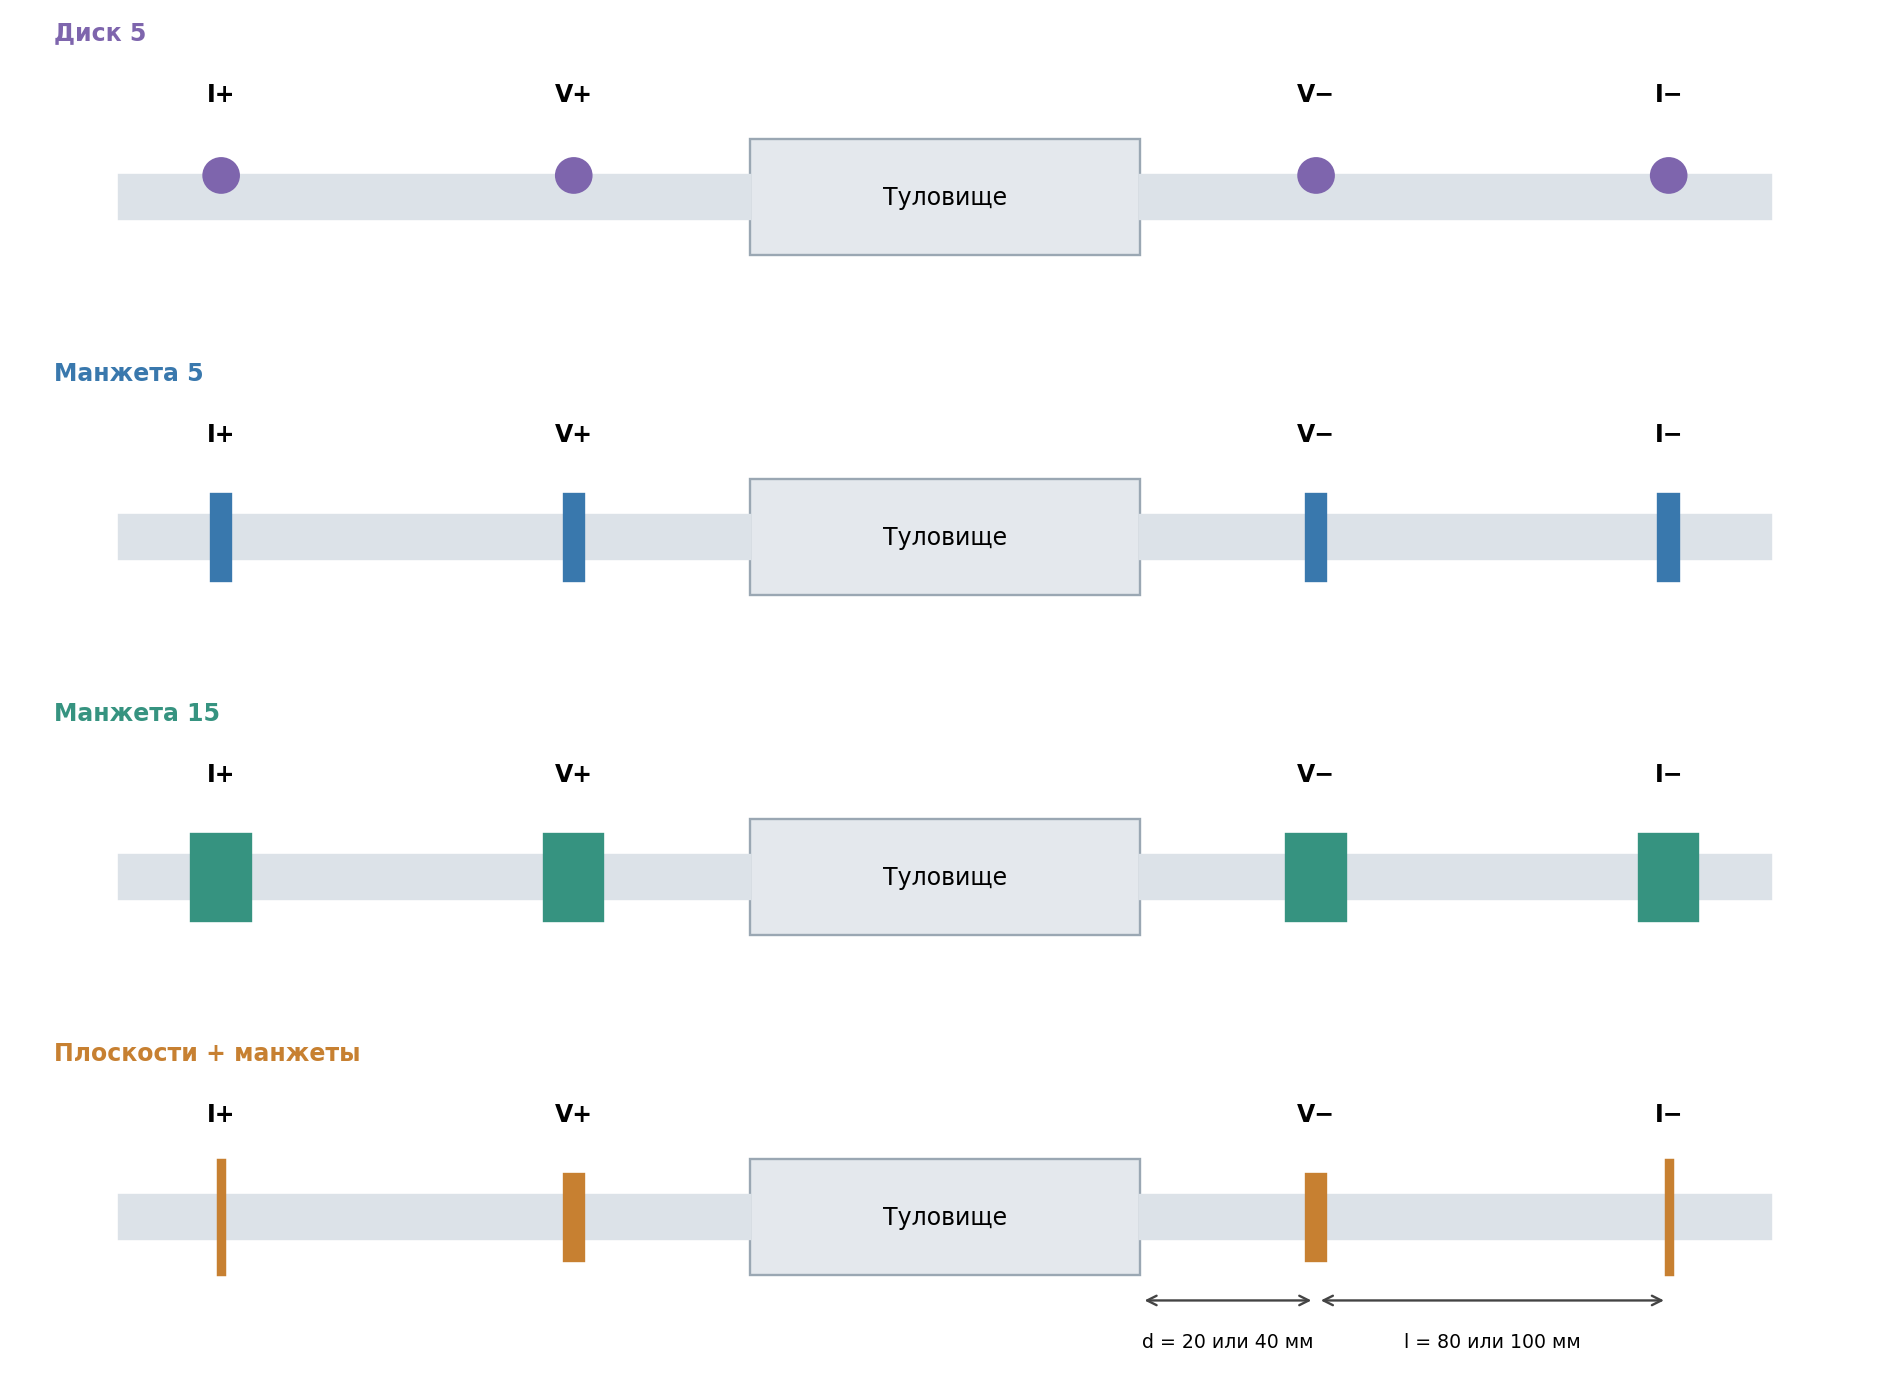

In [4]:
report.montages(r)

**Рисунок 1.** Схема четырёх типов сборок и определения расстояний. Изображение поясняет топологию контактов и их роли; масштаб анатомии условный. Расстояние *d* отсчитывается от плоскости соединения КТ-модели с цилиндрическим продолжением руки до внутреннего электрода, а *l* — от внутреннего до внешнего электрода на той же стороне. Использованы *d* = 20 и 40 мм, *l* = 80 и 100 мм. Это модельные ориентиры; их соответствие точкам наклейки на добровольце отдельно не валидировано.

Для краткой подписи результатов сборка обозначается типом контактов и парой *d/l*. Например, «манжета 5; 20/80» означает ширину контакта 5 мм, расстояние *d* = 20 мм и межэлектродное расстояние *l* = 80 мм. Все численные сравнения относятся к одной и той же токовой и измерительной схеме. Перестановка ролей электродов задаёт другой измерительный канал и должна рассчитываться отдельно.

## 3. Литературные диапазоны удельного сопротивления

### 3.1. Выбранный частотный профиль

Численные ориентиры получены из коэффициентов дисперсионной модели Gabriel в [базе IT’IS, версия 5.0](https://itis.swiss/virtual-population/tissue-properties/downloads/database-v5-0), DOI: 10.13099/VIP21000-05-0. Использована действительная проводимость при 50 кГц. [Описание диэлектрических свойств IT’IS](https://itis.swiss/virtual-population/tissue-properties/database/dielectric-properties) указывает происхождение модели и предупреждает о присвоении некоторым тканям свойств аналогов. Удельное сопротивление вычислено как обратная величина проводимости; частотно не привязанные минимумы и максимумы из других столбцов базы не использовались.

**Таблица 2.** Рабочие интервалы ρ и их литературные ориентиры при 50 кГц. Границы мягкотканного и сердечного интервалов перенесены с отдельных составляющих на эффективный компартмент по решению исследователя. Это модельные диапазоны, а не непосредственно измеренные интервалы изменения всего компартмента.

In [5]:
report.ranges(r)

Компартмент,"ρ min, Ом·м","ρ max, Ом·м","Δρ, Ом·м",Ориентиры
Мягкие ткани,"2,842","23,109","20,266",Мышца — жир
Сердечная область,"1,427","5,117","3,690",Кровь — миокард
Лёгкие,"3,817","9,741","5,924",Спавшееся — наполненное лёгкое


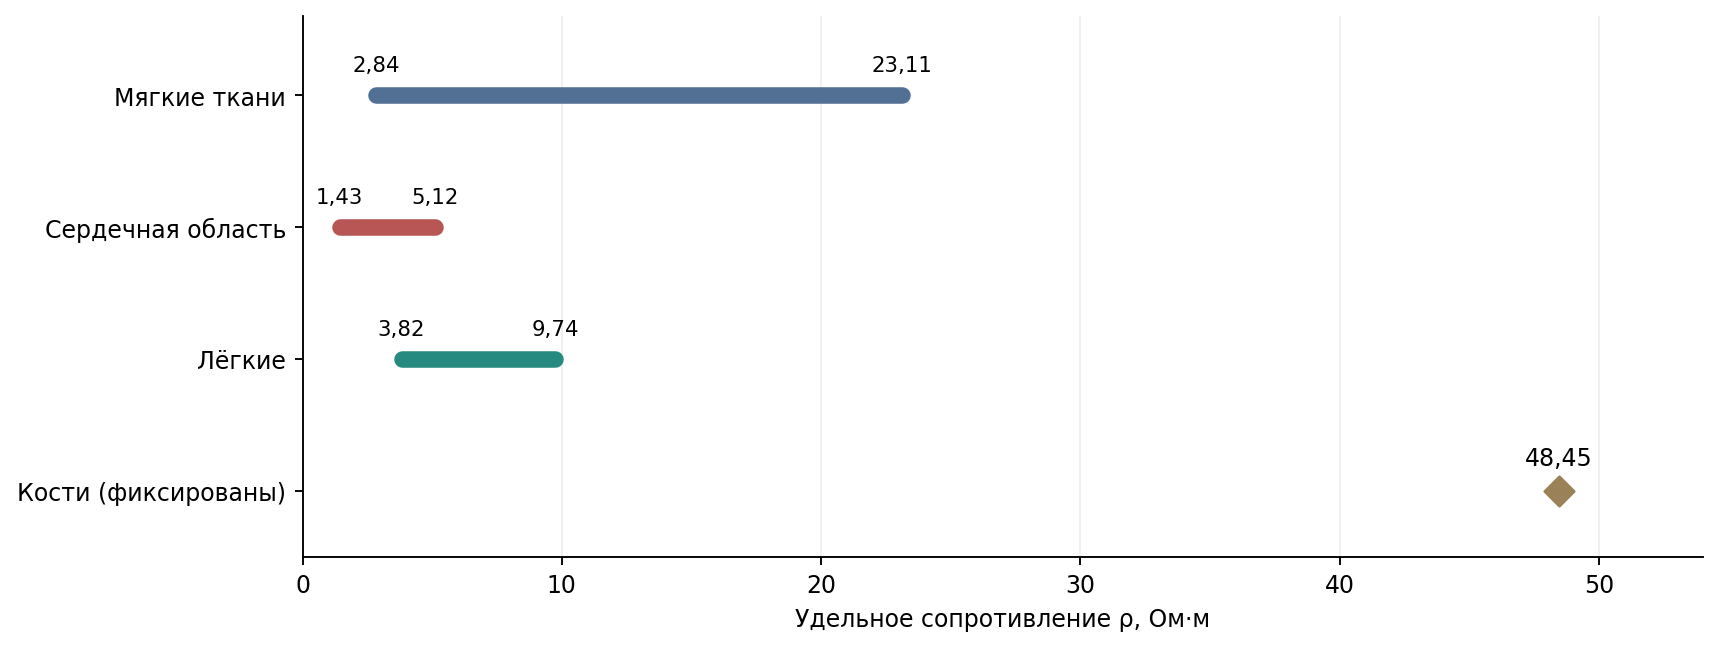

In [6]:
report.range_figure(r)

**Рисунок 2.** Ширина интервалов исходного удельного сопротивления. Отрезки задают общий масштаб сравнения сборок. Они не изображают пульсовое или вентиляционное изменение одного человека. Для костей показано одно фиксированное значение.

**Допущение для мягких тканей.** Интервал между мышечным и жировым ориентирами используется как широкий диапазон эффективного скалярного параметра объединённой области. Он не следует из индивидуально измеренного состава грудной стенки и не является законом смешения. При переходе к другой сегментации, например при выделении отдельных мышц и подкожного жира, этот профиль должен быть пересмотрен вместе с определением параметров.

**Допущение для сердца.** Границы между миокардом и кровью задают диапазон эффективного параметра единой сердечной маски. Промежуточное значение проводимости, сохранённое в исходной сетке, является расчётным сценарием. Ни арифметическая середина проводимостей, ни середина удельных сопротивлений не определяют долю крови без отдельной модели смешения и геометрии полостей.

**Допущение для лёгких.** Ориентиры для наполненного и спавшегося лёгкого используются при неизменной КТ-геометрии. Такой расчёт отделяет влияние электрического параметра от геометрических изменений. Он не воспроизводит полный переход от вдоха к выдоху, при котором изменяются объём, форма и взаимное положение органов. Историческое значение ρ лёгких 17,4067 Ом·м, полученное из прежней настройки модели, исключено из основного литературного профиля. Соответствующие старые расчёты сохранены, но не участвуют в текущих сводках.

### 3.2. Неопределённость выбора литературного профиля

Современная работа [Kangasmaa, Laakso, Schmid, 2025](https://onlinelibrary.wiley.com/doi/10.1002/bem.22541) объединяет измерения на предплечьях десяти добровольцев и моделирование, причём мышца описана как анизотропная среда. По коэффициентам их таблицы 3 при 50 кГц здесь вычислены ρ жира 4,79 Ом·м, поперечной мышцы 4,64 Ом·м и продольной мышцы 1,52 Ом·м. Это значения аппроксимации центральных оценок, а не границы интервала неопределённости. Они показывают зависимость ориентиров от модели и направления; в частности, продольный мышечный ориентир выходит за нижнюю границу принятого скалярного профиля.

Следовательно, выбранный профиль Gabriel/IT’IS обеспечивает воспроизводимость текущего сравнения, но не доказывает охват всей физиологической вариабельности. Перенос продольной проводимости мышцы на целый неоднородный компартмент также требует допущения. Для будущего решения о конкретной сборке нужен отдельный анализ устойчивости вывода к альтернативному тканевому профилю или анизотропной постановке. Эта неопределённость отличается от недостаточной плотности расчётной сетки внутри уже выбранного интервала.

## 4. Математическое определение чувствительности

### 4.1. Передаточный импеданс и производная по ρ

Для сборки *i* рассматривается передаточный импеданс при фиксированном контакте и геометрии:

$$
Z_i(\boldsymbol\rho)=\frac{U_{i,+}-U_{i,-}}{I_i},\qquad
\boldsymbol\rho=(\rho_{\mathrm{soft}},\rho_{\mathrm{heart}},\rho_{\mathrm{lung}}),
\tag{1}
$$

где $U_{i,+}$ и $U_{i,-}$ — потенциалы измерительных электродов, В; $I_i$ — ток возбуждения, А; $Z_i$ — передаточный импеданс, Ом; компоненты $\boldsymbol\rho$ выражены в Ом·м. В решателе ток нормирован к 1 А, что служит вычислительной нормировкой линейной задачи, а не утверждением о токе прибора.

В данной модели используются действительные скалярные проводимости. Поэтому ρ = 1/σ, а переход сохранённой производной по проводимости к искомой величине точен:

$$
S_{it}(\boldsymbol\rho)=\frac{\partial Z_i}{\partial\rho_t}
=-\sigma_t^2\frac{\partial Z_i}{\partial\sigma_t},
\tag{2}
$$

где *t* обозначает компартмент; $S_{it}$ имеет размерность Ом/(Ом·м), или м⁻¹. Частная производная вычисляется при фиксированных остальных параметрах в одном исходном состоянии. Между состояниями изменяются все три исходных параметра. Поэтому результат является функцией совместного состояния, а не одним коэффициентом около единственной исходной точки.

В EIDORS-постановке тканевая часть матрицы системы линейна по проводимостям. При неизменных контактах производная получается из прямого и взаимного решений:

$$
K=C+\sum_t\sigma_t B_t,\qquad
K u=q_I,\quad K v=q_V,\qquad
\frac{\partial Z}{\partial\sigma_t}=-v^\mathsf{T}B_tu,
\tag{3}
$$

где *C* — контактная часть матрицы; $B_t$ — матрица единичной проводимости компартмента; *u* и *v* — решения для токового и взаимного возбуждений; $q_I$ и $q_V$ — соответствующие нормированные правые части. Потенциал фиксируется в одном опорном узле. Сумма по тканям включает кости, хотя их проводимость в текущей матрице состояний постоянна.

Подготовка геометрии и матриц выполнена в существующей MATLAB/EIDORS-ветке. Новые состояния решаются Python-модулем с PARDISO, вызванным через каноническую функцию `run_pipeline`. Таким образом, повторно используется одна и та же конечно-элементная постановка. Отдельная факторизация в каждом новом состоянии учитывает перераспределение поля при изменении фоновых параметров.

### 4.2. Почему не требуется деление на объём

Производная в выражении (2) относится к изменению всего компартмента и уже учитывает его объём, расположение и поле внутри него. В пространственном представлении вклад суммируется со знаком по всем элементам маски. Если различные участки дают противоположные вклады, они компенсируются именно так, как требует равномерное изменение параметра всей области.

Деление результата на объём изменило бы исследовательский вопрос: получилось бы среднее значение на единицу объёма, полезное для другой постановки, но не равное отклику целого органа или объединённого фона. Замена знаковой суммы суммой модулей также изменила бы физический смысл. В текущем протоколе сначала получают интегральную производную всего компартмента, и только затем при необходимости рассматривают её модуль для сравнения амплитуд.

Производная является локальной по **пространству параметров**: это наклон функции в заданном исходном состоянии. Такая математическая локальность не вводит локальную анатомическую пробу. Новая конечная разность ±1% не нужна для определения этой производной, поскольку она вычисляется из матриц и двух полей. Конечные разности могут служить отдельной проверкой реализации, а не заменой исследования диапазона исходных состояний.

### 4.3. Показатели для сравнения сборок

Первичный показатель — знаковая производная $S_{it}$. Она отвечает на вопрос, как изменится импеданс при одинаковом малом изменении ρ целевого компартмента. Для согласованного сравнения влияния разных компартментов вводится общий для всех сборок масштаб:

$$
\Delta\rho_t=\rho_{t,\max}-\rho_{t,\min},\qquad
B_{it}=|S_{it}|\Delta\rho_t,
\tag{4}
$$

где $\Delta\rho_t$ — ширина выбранного литературного интервала, Ом·м; $B_{it}$ — модуль линейно масштабированной чувствительности, Ом. Это производная, умноженная на ширину интервала в конкретном исходном состоянии. При нелинейной зависимости она не равна конечному изменению импеданса через весь интервал.

Для каждого компартмента поочерёдно как цели рассчитываются избирательность и отношение влияния остальных параметров к целевому:

$$
Q_{it}=\frac{B_{it}}{\sum_k B_{ik}},\qquad
N_{it}=\frac{\sum_{k\ne t}B_{ik}}{B_{it}},
\tag{5}
$$

где *k* пробегает три изменяемых компартмента. $Q_{it}$ безразмерен и лежит от 0 до 1; в таблицах он может выражаться в процентах. Чем больше *Q* и меньше *N*, тем слабее относительное влияние остальных параметров при принятом масштабе сравнения. Это не доля измеренного физиологического сигнала, не отношение сигнал/шум и не вероятность правильного восстановления. В знаменателе используются модули интегральных вкладов, поэтому противоположные знаки разных компартментов не создают искусственно высокой избирательности за счёт компенсации.

При нулевой сумме вкладов избирательность не определена. При практически нулевой цели отношение *N* также не определено; программный модуль возвращает явную маску и пропуск, а не большое произвольное число. Кости и контакт в знаменатель не включены, поскольку для них не задан масштаб изменения. Если набор неопределённых параметров расширится, показатель необходимо пересчитать.

Конечный отклик оценивается отдельной величиной:

$$
E_{it}(\boldsymbol\rho_{-t})=
\left|Z_i(\rho_{t,\max},\boldsymbol\rho_{-t})-
Z_i(\rho_{t,\min},\boldsymbol\rho_{-t})\right|,
\tag{6}
$$

где $\boldsymbol\rho_{-t}$ обозначает фиксированные значения остальных параметров; *E* выражается в омах. Здесь используются два реальных FEM-решения, а не линейное продолжение производной. *E* — разность между границами; при немонотонной зависимости она может быть меньше полного размаха функции внутри интервала. Монотонность между всеми непрерывными состояниями заранее не предполагается.

Набор $S$, $B$, $Q$, $N$ и $E$ образует численное описание сборки. Единого взвешенного рейтинга не вводится: большая абсолютная чувствительность и высокая избирательность являются разными требованиями. Для нового целевого канала сначала задаются цель и допустимое влияние остальных параметров, после чего сборки сравниваются в одной области состояний.

## 5. План расчётов и проверка покрытия диапазона

### 5.1. Исходные и проверочные состояния

После исключения исторического значения лёгких исходная матрица содержит 3 уровня мягкотканного фона, 3 уровня сердечной области и 2 уровня лёгких. Получается 18 сочетаний на сборку и 288 ранее выполненных решений для 16 сборок. Все сочетания этих узлов действительно присутствуют. Однако уровни, заданные первоначально через σ, распределены по ρ неравномерно.

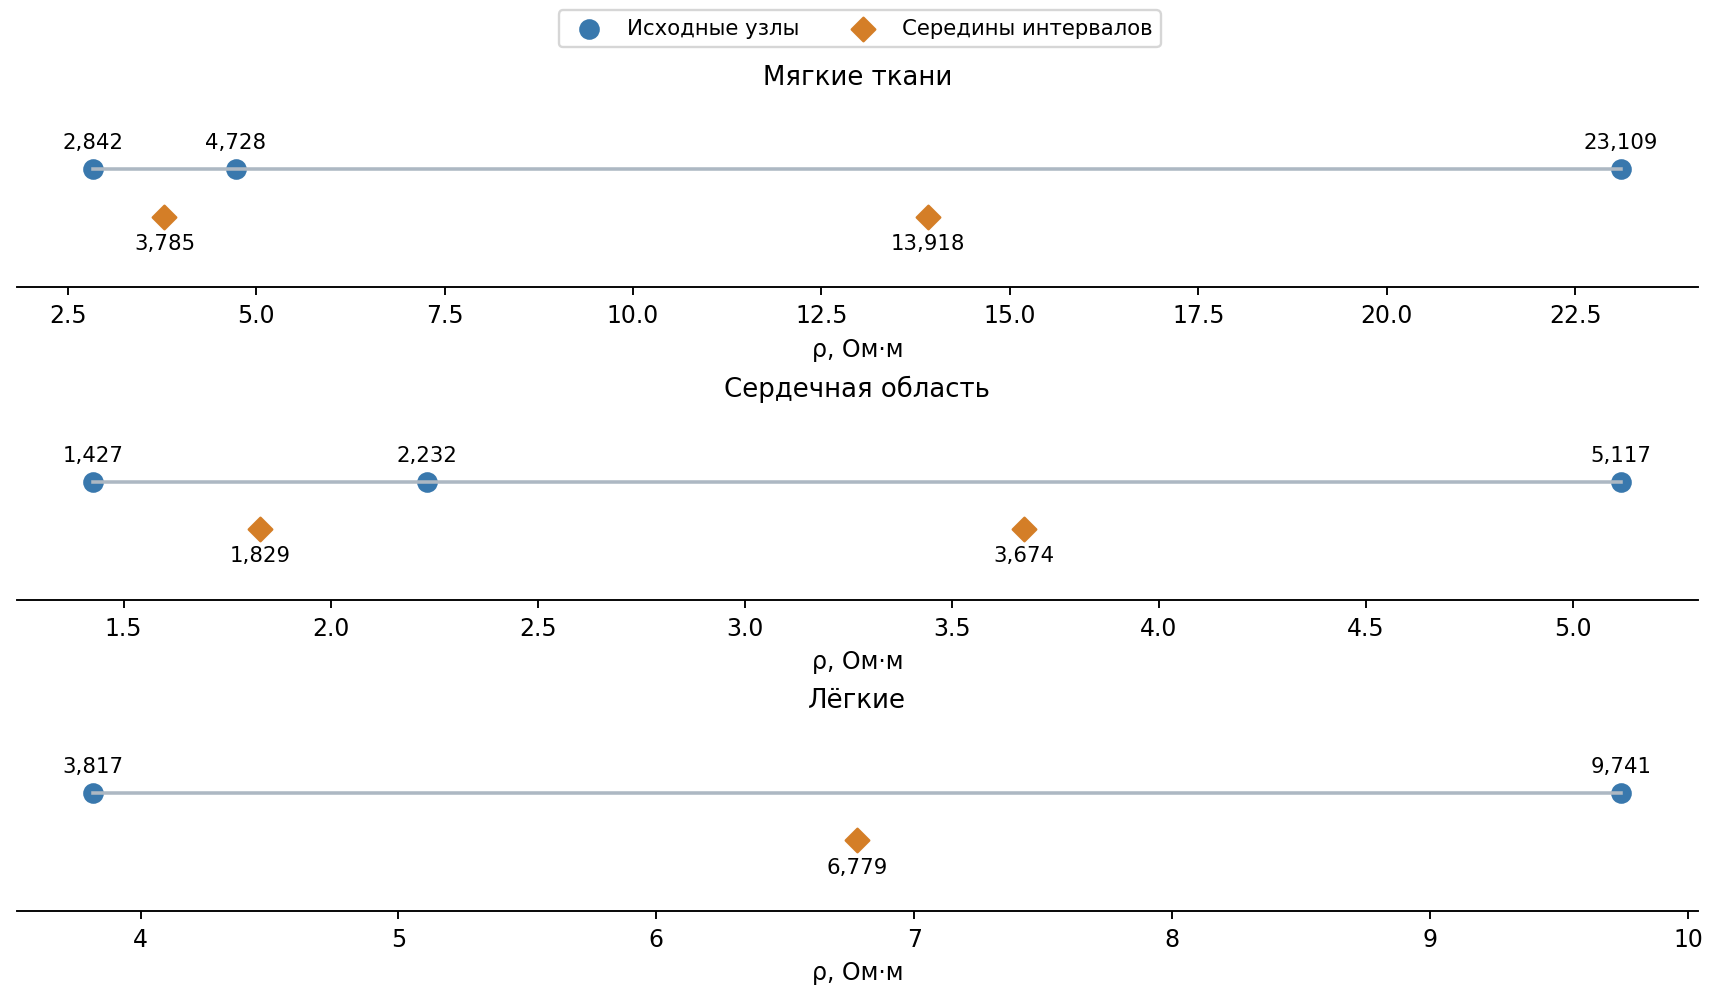

In [7]:
report.axes(r)

**Рисунок 3.** Узлы исходной сетки по каждой координате ρ и новые координаты середин интервалов. Большой промежуток между отдельными уровнями мягкотканного фона особенно важен: наличие трёх значений само по себе не означает равномерного покрытия диапазона. Точки в этой одномерной схеме обозначают координаты; новые трёхмерные расчёты выполнены в сочетаниях середин, показанных на рисунке 4.

Исходная сетка образует четыре прямоугольные ячейки: две по ρ мягких тканей, две по ρ сердца и одну по ρ лёгких. В центре каждой ячейки по координатам **ρ** рассчитывается новое совместное состояние. Для каждой из 16 сборок выполнены четыре независимых решения, всего 64. В этих состояниях изменены все три фоновых параметра, а производные получены непосредственно из нового решения, без интерполяции старых полей.

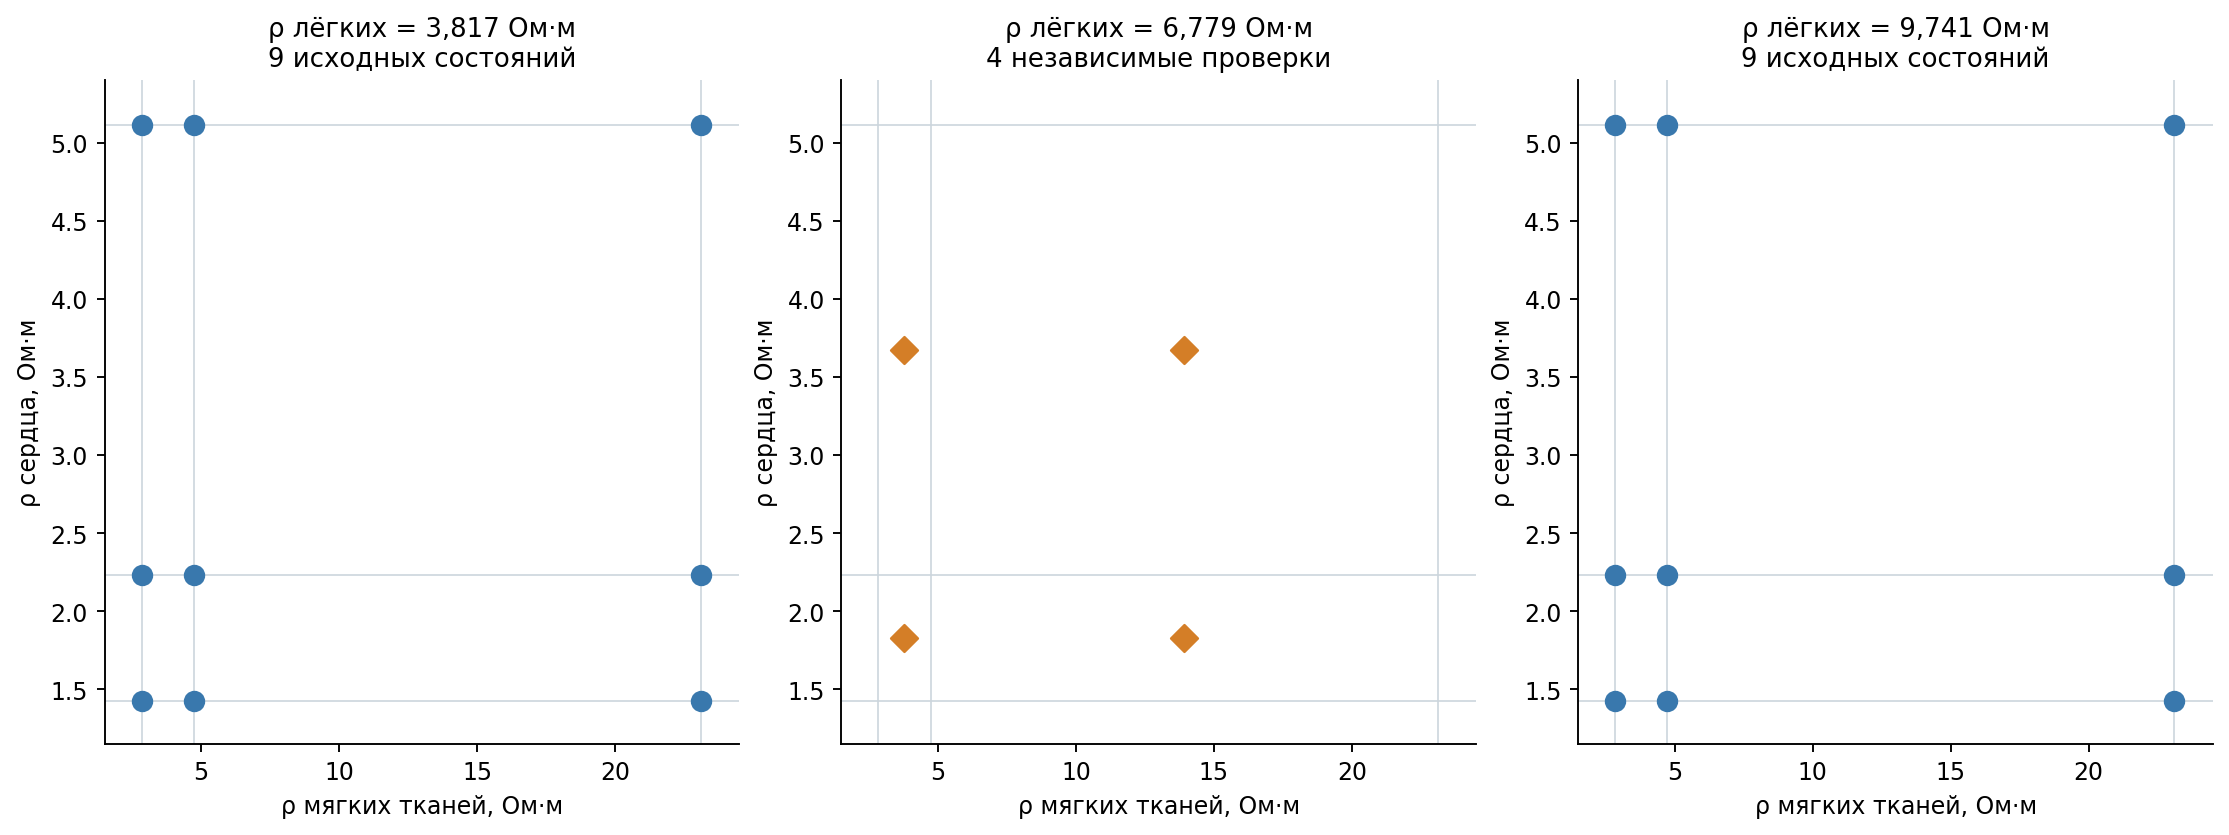

In [8]:
report.grid(r)

**Рисунок 4.** Область совместных состояний в трёх сечениях по ρ лёгких: две границы и середина интервала. Синие точки — 18 исходных сочетаний, оранжевые — четыре центра ячеек. Для каждой сборки используются одинаковые точки. Новые состояния проверяют внутренность ячеек; они не образуют полного равномерного сгущения каждой координатной оси.

### 5.2. Предварительно заданный критерий

Из исходных производных строится трилинейная интерполяция по координатам ρ. Её прогноз в центре ячейки сравнивается с независимой FEM-производной. Принят следующий технический критерий:

$$
\left|\widehat S_{it}-S_{it}^{\mathrm{FEM}}\right|
\leq 0{,}05\left|S_{it}^{\mathrm{FEM}}\right|
+0{,}005\max_{\mathrm{исх.\ узлы}}|S_{it}|,
\tag{7}
$$

где $\widehat S_{it}$ — интерполированная производная; $S_{it}^{\mathrm{FEM}}$ — непосредственно рассчитанная производная в проверочном состоянии. Второе слагаемое ограничивает влияние деления на малую величину. Максимум в нём берётся отдельно для той же сборки и компартмента. Допуск задан исследователем до анализа новых решений; он не взят из физиологической литературы и не задаёт точность прибора.

Дополнительно оценивается ошибка *Q*. Для неё выбран абсолютный допуск 0,005, то есть 0,5 процентного пункта. Сам показатель вычисляется из интерполированных производных, а затем сравнивается с показателем из прямого FEM-решения. Маленькая абсолютная ошибка малой избирательности может сочетаться с заметной относительной ошибкой целевой производной; поэтому одного контроля *Q* недостаточно.

Проверка внутренних точек допускает отрицательный вывод о достаточности старой сетки. Даже если бы все центры прошли допуск, это не доказывало бы точность во всех непрерывных состояниях: края ячеек и иные внутренние точки могут вести себя иначе. В текущей работе нет математической верхней оценки ошибки по всему параллелепипеду. Проверка параметрического покрытия также не заменяет сходимости при измельчении пространственной FEM-сетки.

## 6. Результаты вычислительного исследования

### 6.1. Передаточный импеданс и зависимость от исходного состояния

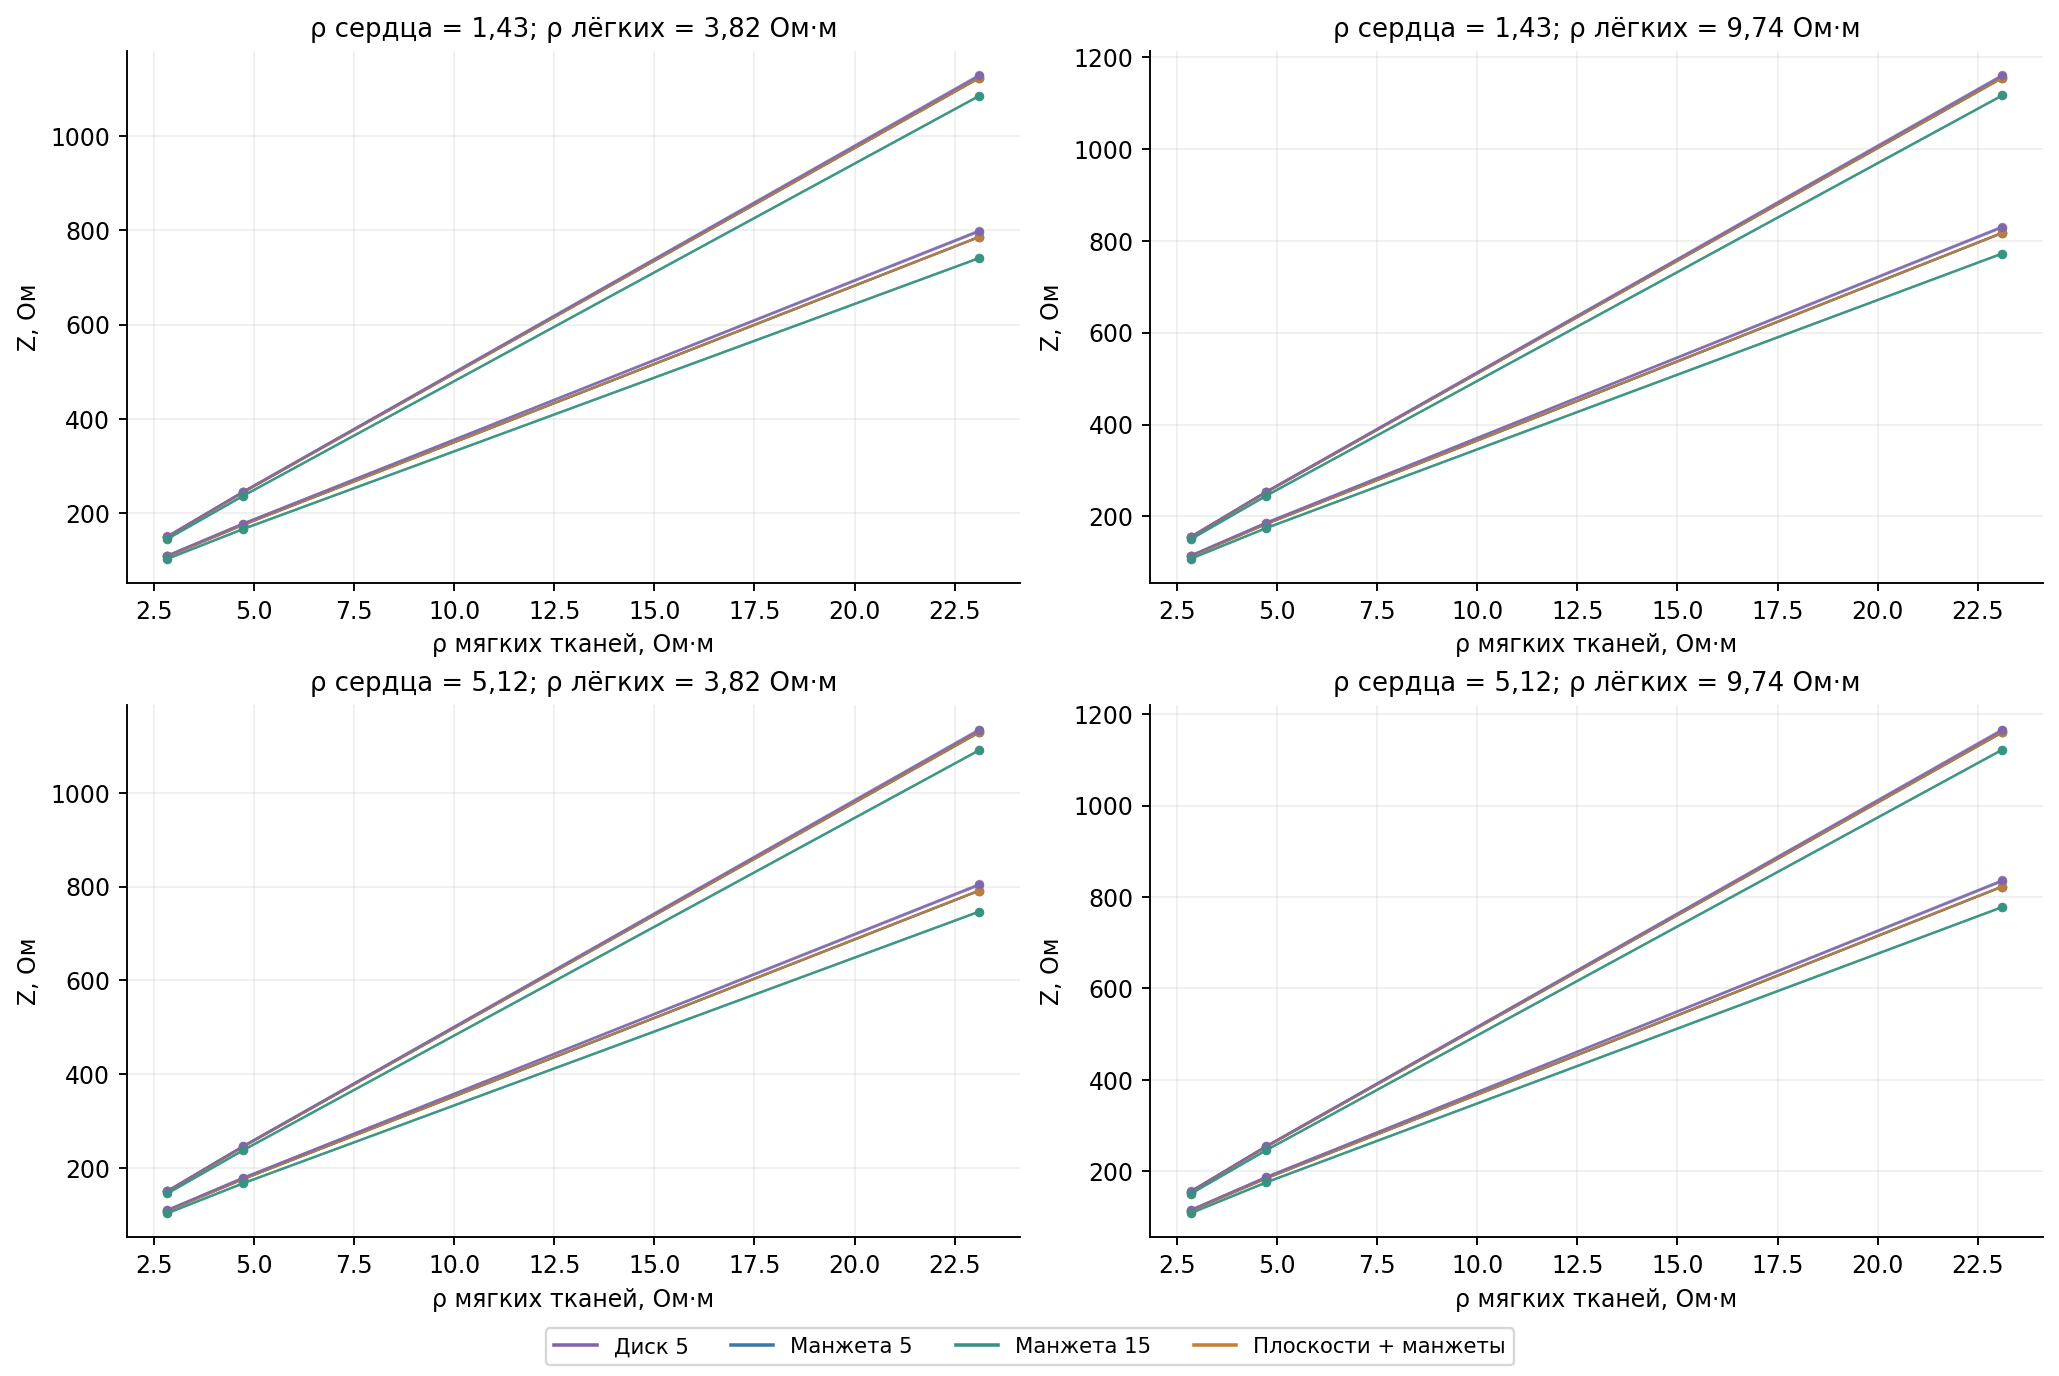

In [9]:
report.z_curves(r)

**Рисунок 5.** Передаточный импеданс как функция ρ мягкотканного фона при четырёх граничных сочетаниях ρ сердца и лёгких. Показаны все 16 сборок. Линии соединяют рассчитанные узлы и служат визуальными направляющими, а не дополнительными решениями. Разброс между панелями показывает влияние остальных компартментов при изменении одной и той же координаты.

Изменение базового импеданса необходимо отличать от чувствительности к выбранному параметру. Сборка с большим *Z* не обязана иметь большую сердечную чувствительность. Нормирование всех производных на *Z* могло бы изменить порядок сборок и было бы неустойчивым для каналов с малым передаточным импедансом. Поэтому основные показатели здесь вычислены без такого деления.

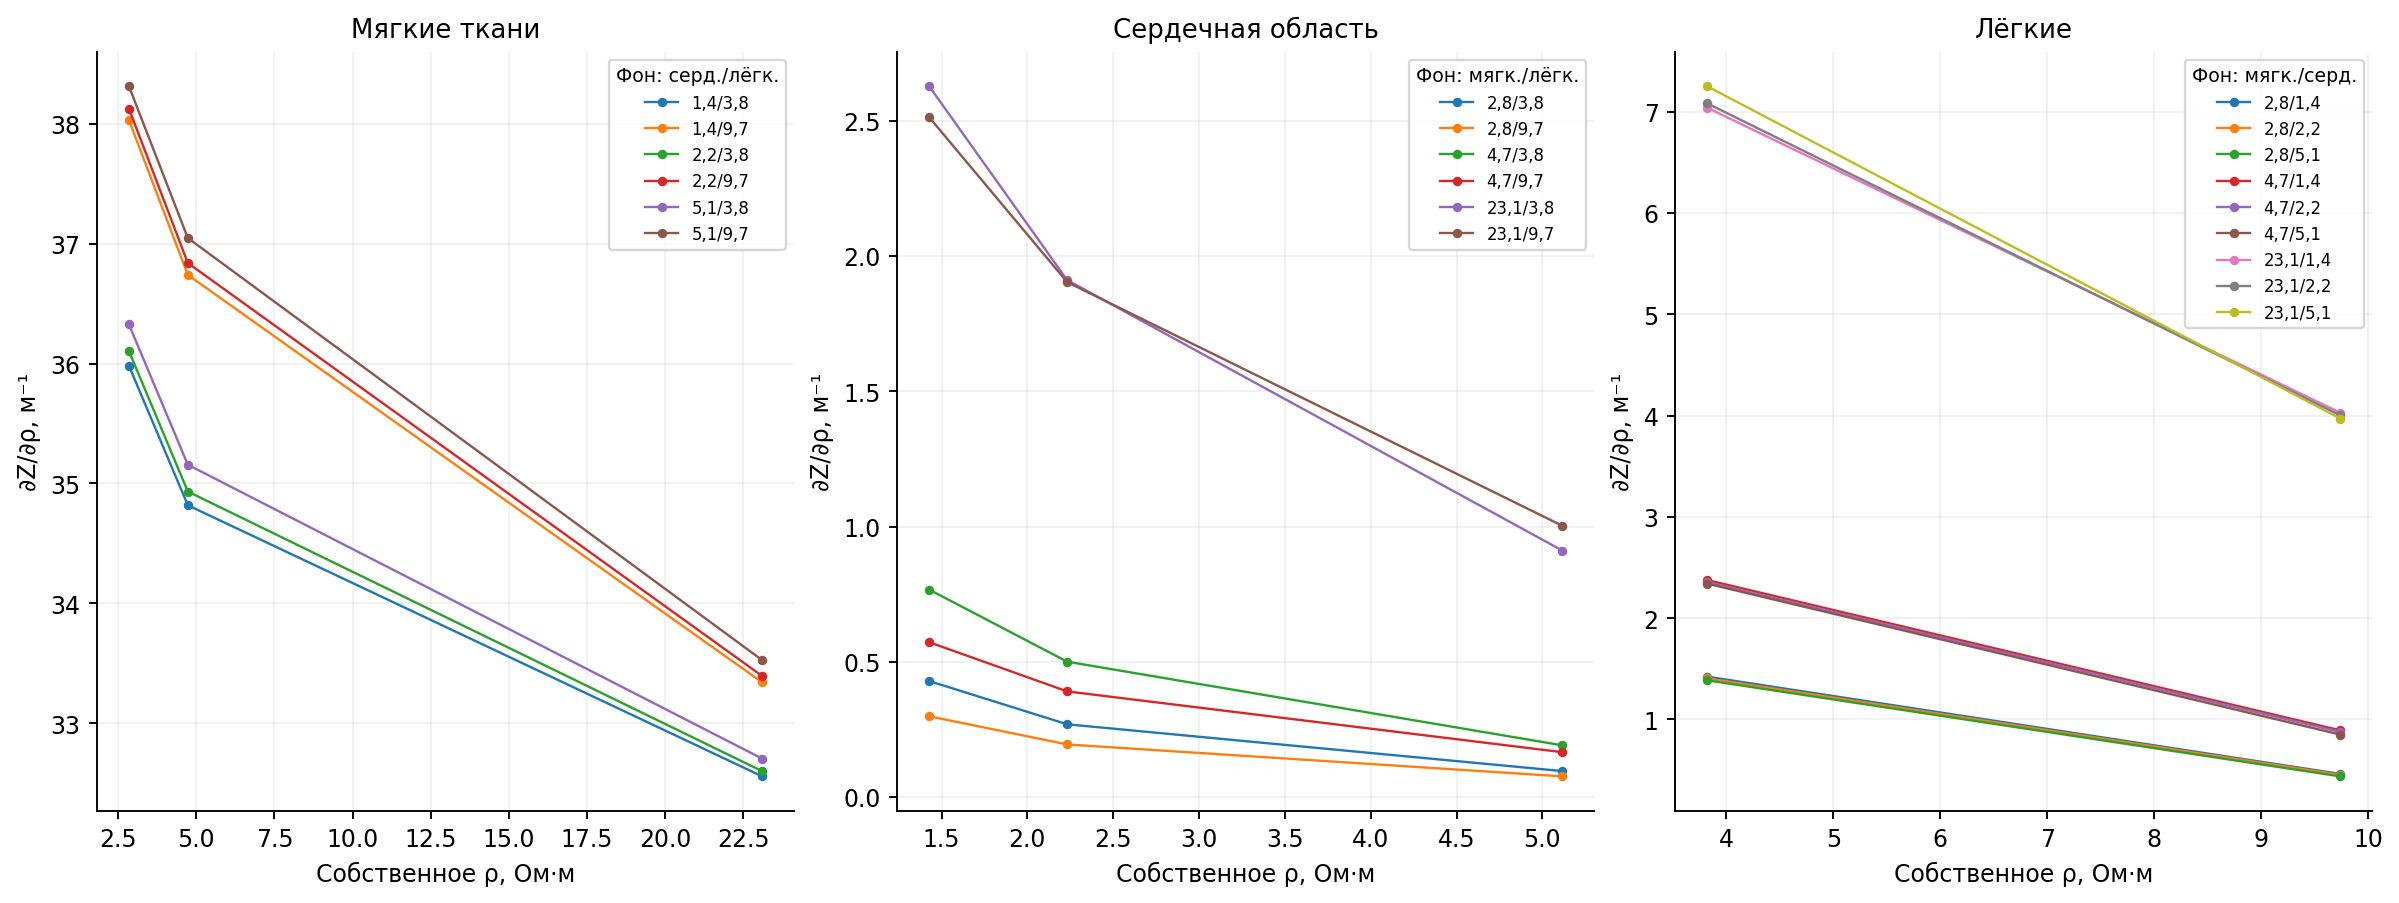

In [10]:
report.derivative_curves(r)

**Рисунок 6.** Производные по трём целым компартментам для опорной сборки «манжета 5; 20/80». По горизонтали отложено собственное ρ соответствующего компартмента. Разные линии соответствуют различным рассчитанным сочетаниям остальных параметров. Шкалы по вертикали различаются: это необходимо для чтения зависимостей малого сердечного и более крупного мягкотканного отклика. Производные других сборок приведены в общей сводке ниже.

Если линии одного компартмента расходятся, чувствительность зависит не только от его собственного параметра, но и от окружающего фона. Это и есть основание для совместного перебора. Одна производная в условной исходной точке не описывает весь набор состояний; вместе с тем замена производной одним конечным откликом также потеряла бы информацию о меняющемся наклоне функции.

### 6.2. Абсолютная чувствительность и избирательность

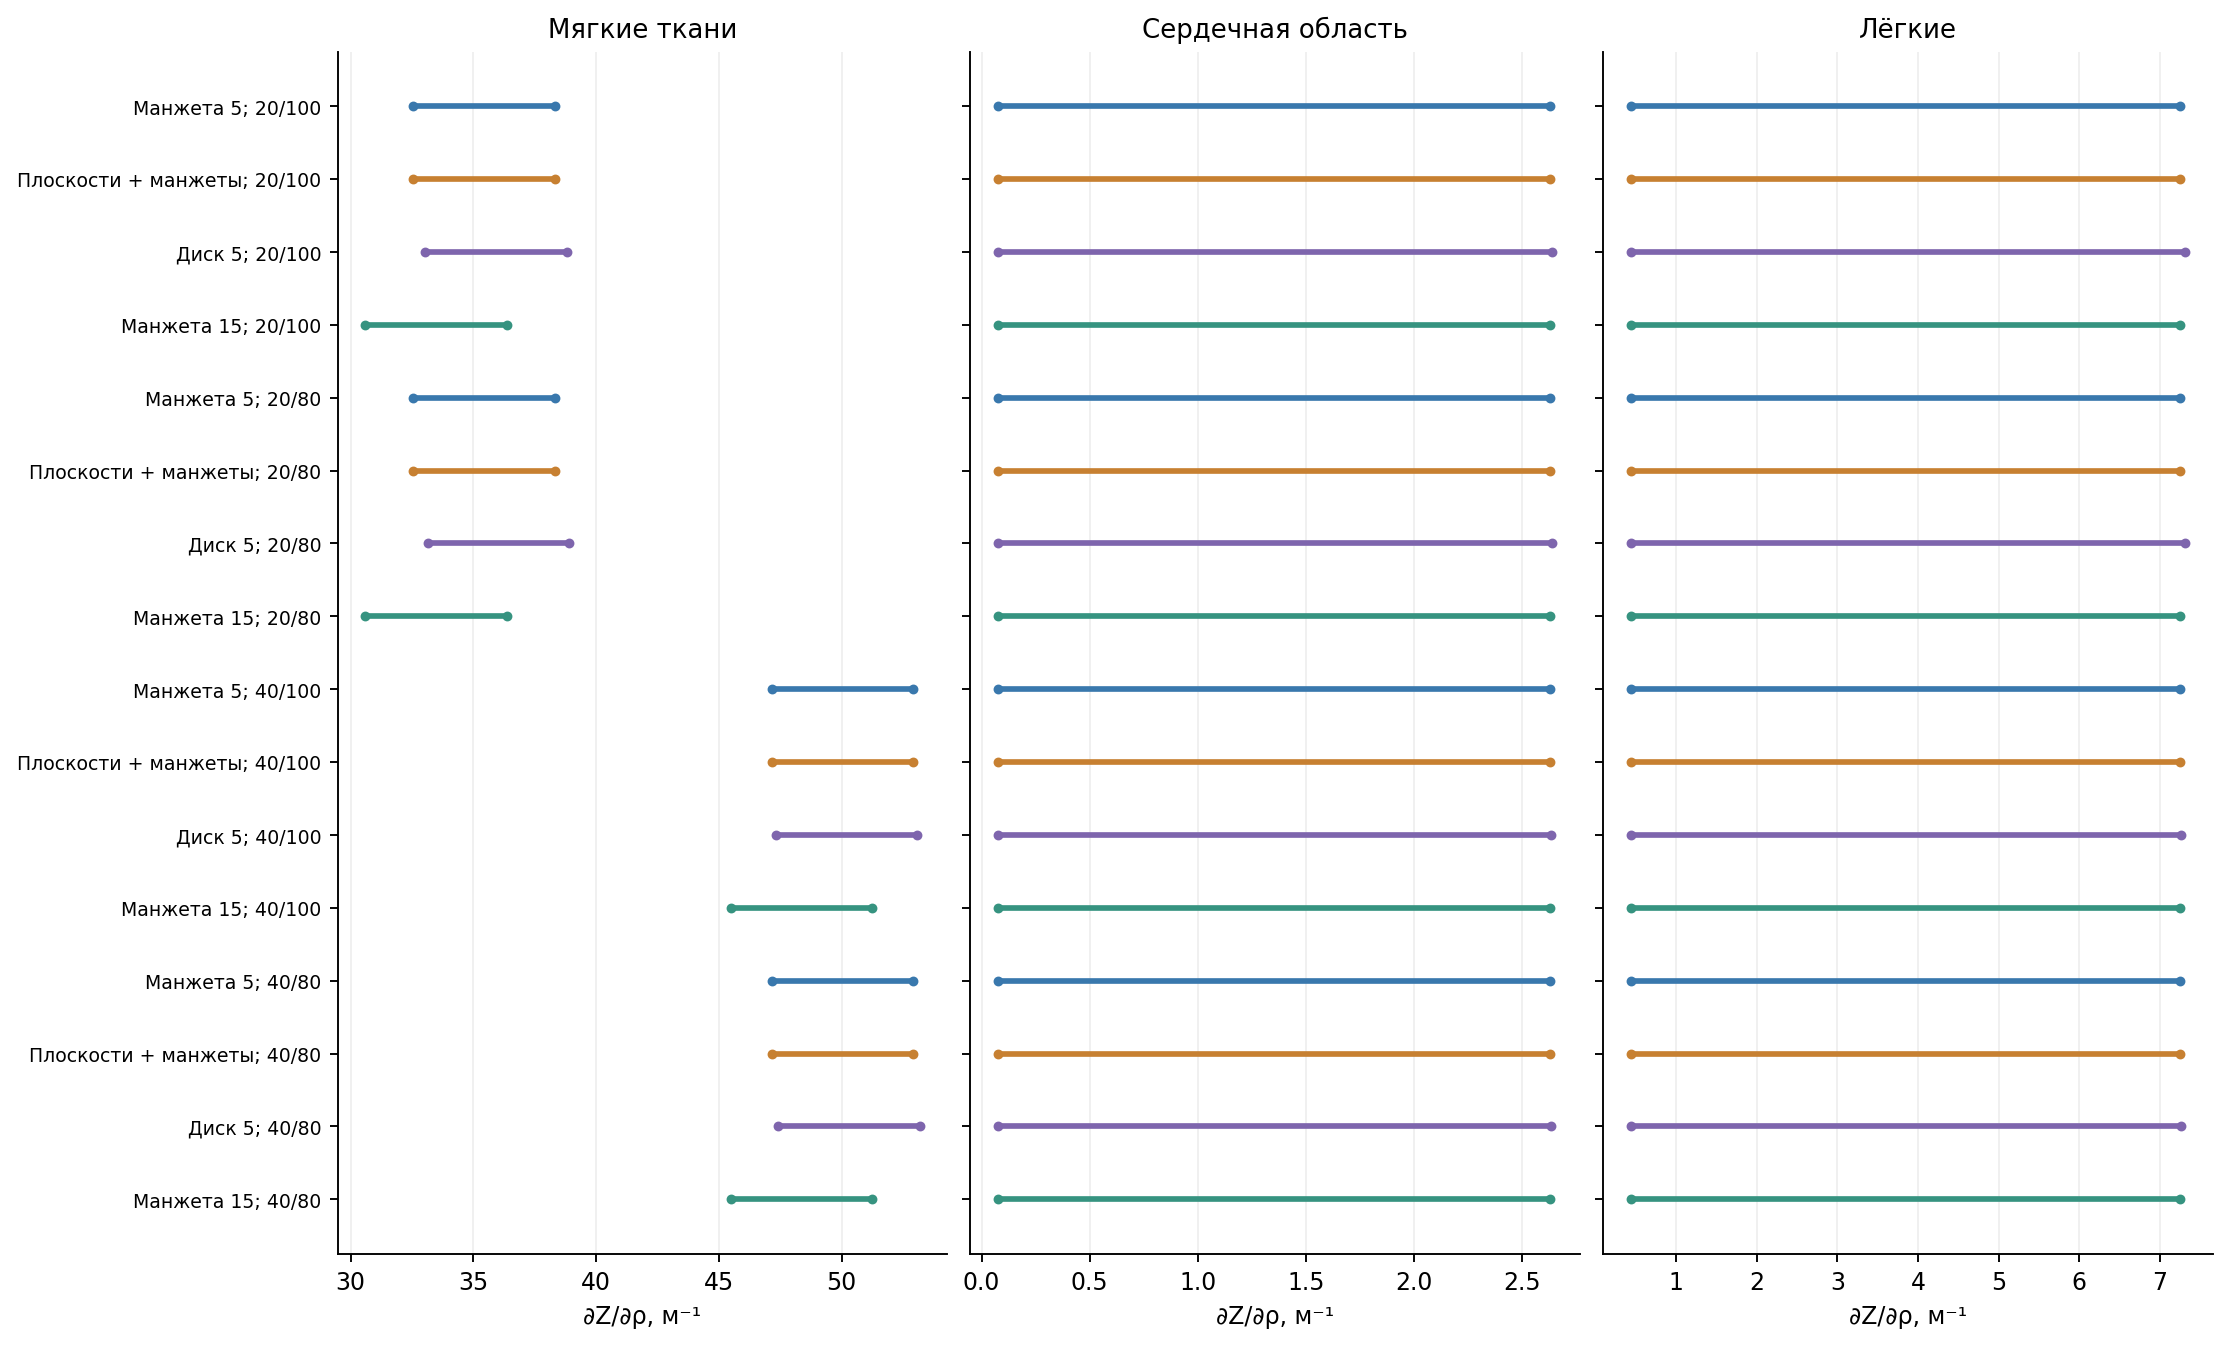

In [11]:
report.s_ranges(r)

**Рисунок 7.** Найденные интервалы производных всех 16 сборок по 22 рассчитанным состояниям на сборку: 18 исходным и четырём проверочным. Концы отрезков — минимальное и максимальное рассчитанные значения. Это сеточные экстремумы, а не гарантированные границы непрерывной функции. Горизонтальные шкалы внутри каждого столбца общие для всех сборок, что позволяет сопоставлять их непосредственно.

**Таблица 3.** Общие найденные диапазоны показателей по всем 16 сборкам и рассчитанным состояниям.

In [12]:
report.result_summary(r)

Компартмент,"∂Z/∂ρ, м⁻¹","Q, %","E, Ом"
Мягкие ткани,"30,6047–53,1833","92,347–99,734","637,942–1010,228"
Сердечная область,"0,0766–2,6385","0,026–1,444","0,541–5,707"
Лёгкие,"0,4383–7,3152","0,240–6,416","4,548–31,451"


**Результат модели.** Таблица объединяет все сборки и рассчитанные состояния. Во всех найденных узлах производные трёх компартментов положительны; это наблюдение по узлам, а не доказательство монотонности на всей непрерывной области. Мягкотканный фон имеет наибольшую чувствительность при принятом определении маски и литературном масштабе.

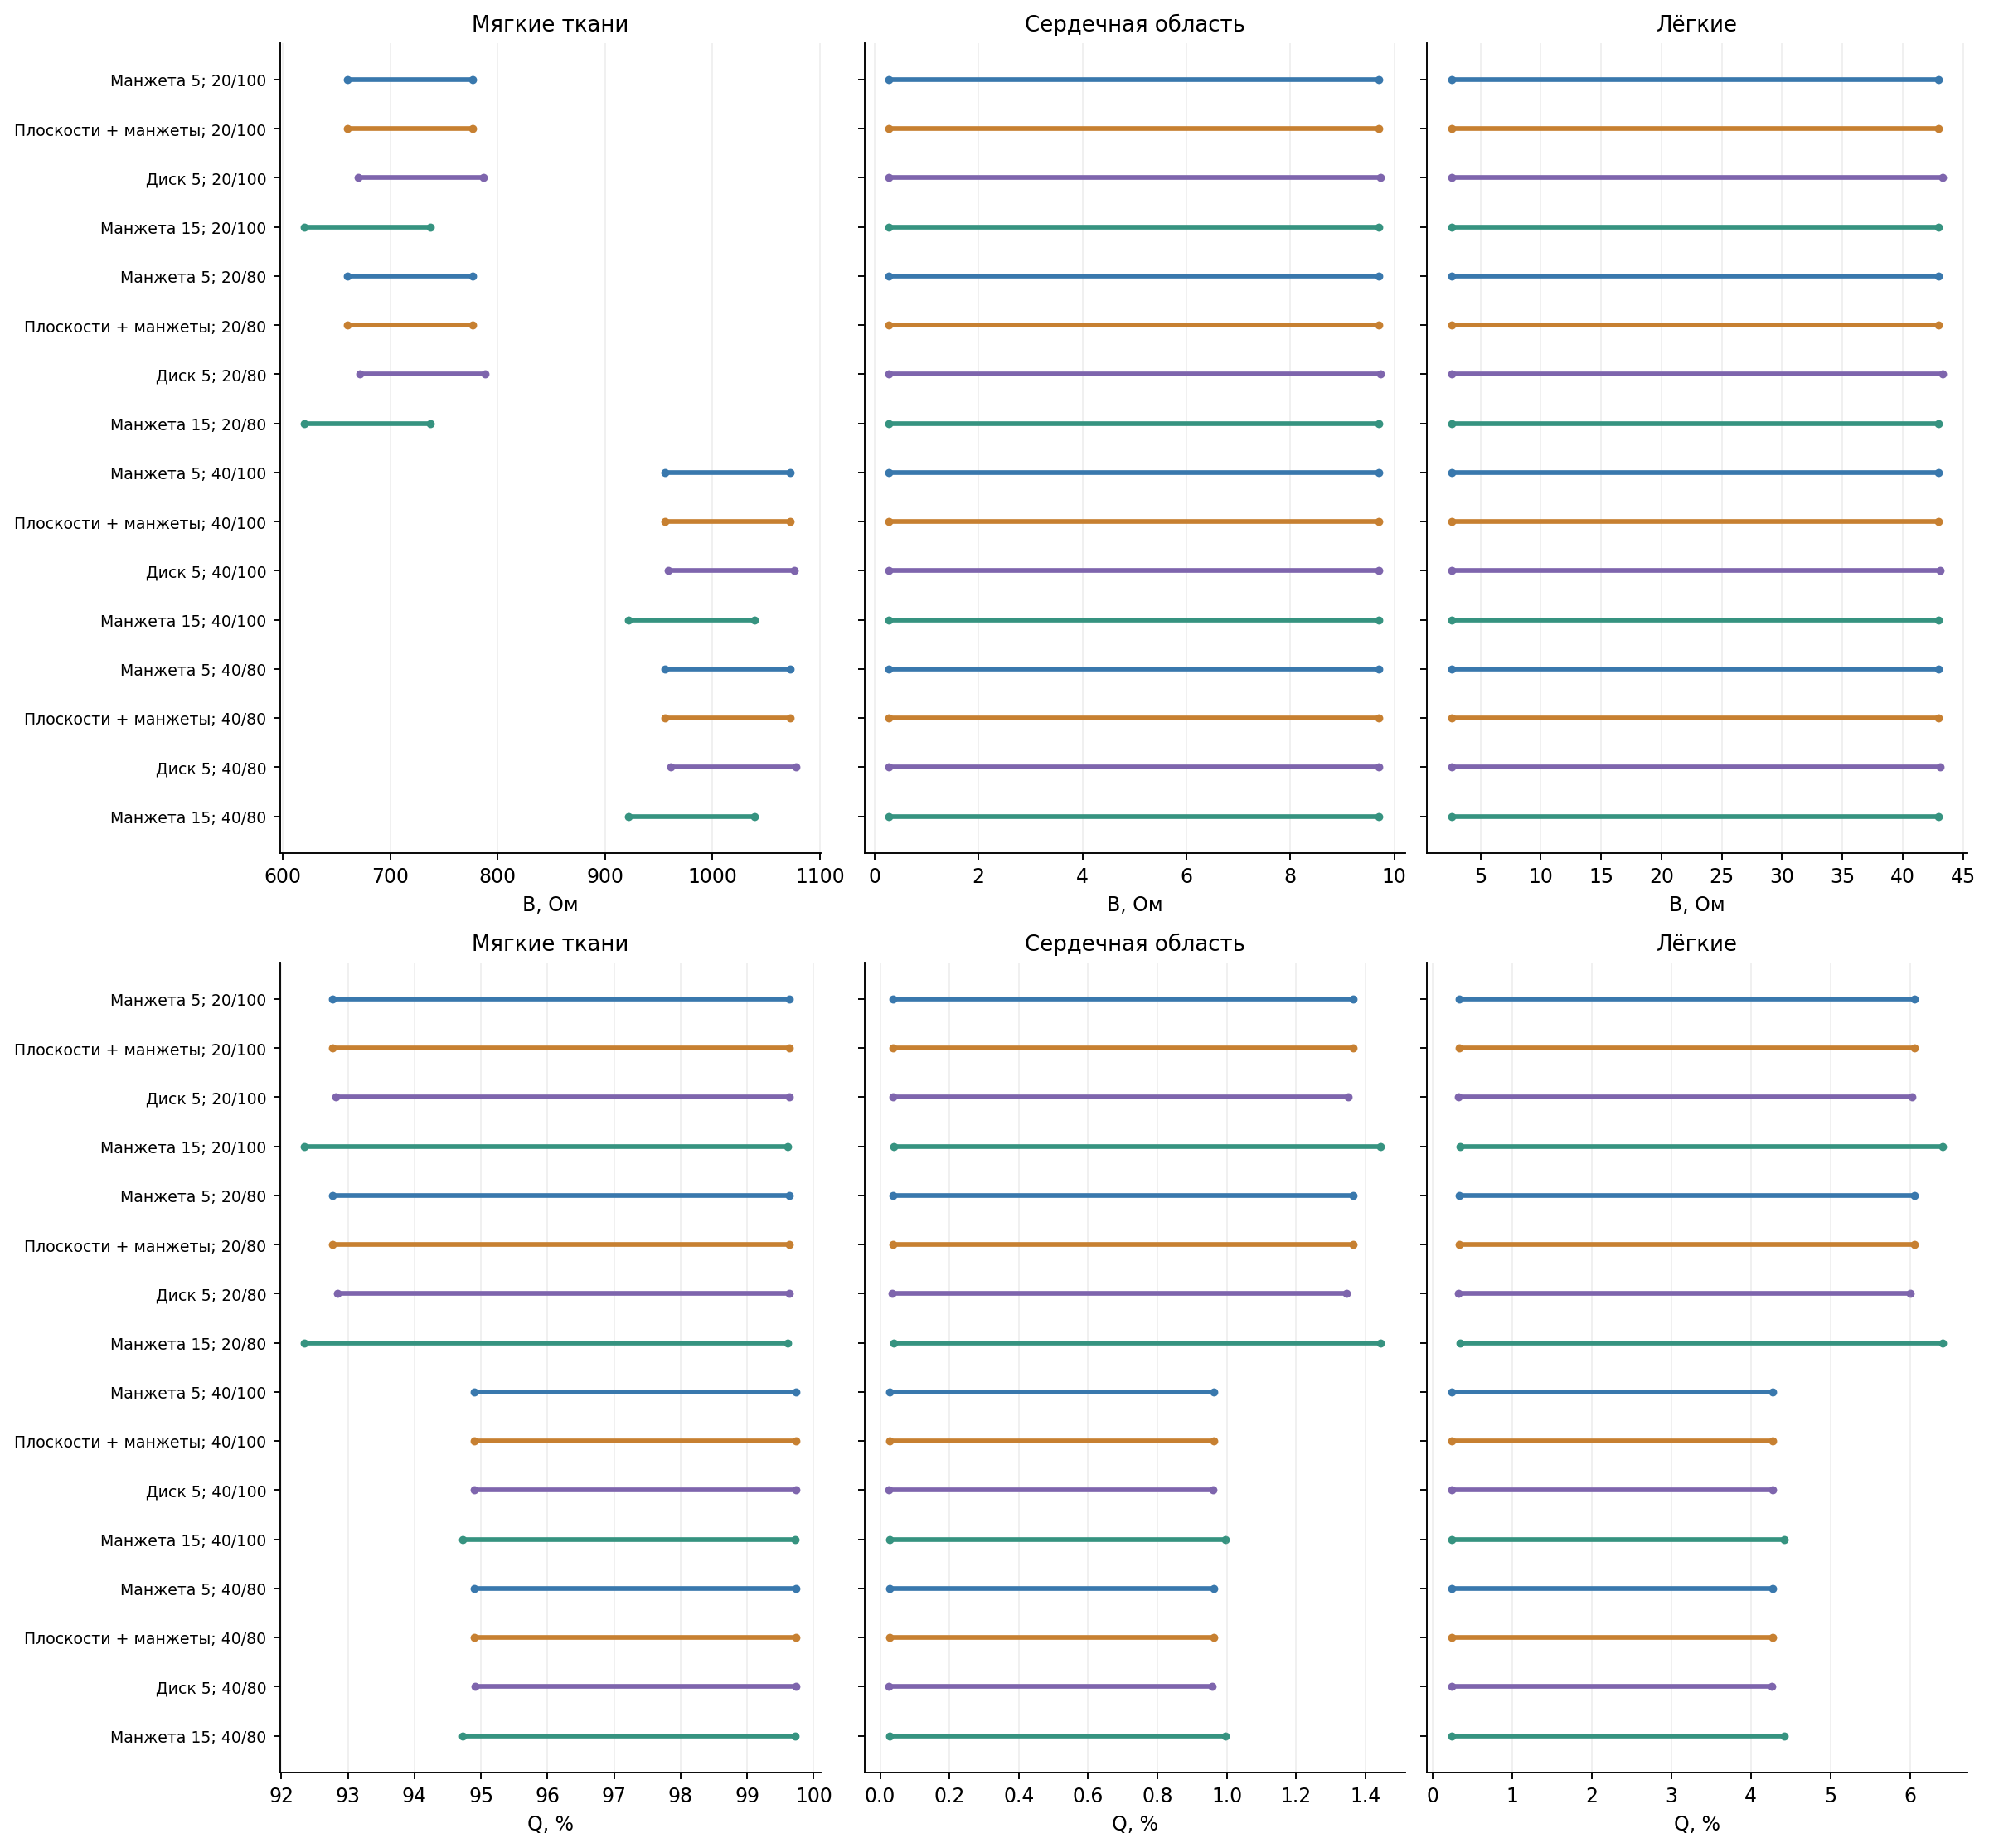

In [13]:
report.bq_ranges(r)

**Рисунок 8.** Линейно масштабированная чувствительность *B* и избирательность *Q*. Верхний ряд показывает диапазон амплитуд в омах при умножении производной на ширину литературного интервала; нижний — соответствующий диапазон избирательности. Все сборки оцениваются с одним набором масштабов. Ширина отрезка характеризует зависимость показателя от исходного состояния и не является доверительным интервалом.

Высокая мягкотканная избирательность в этом примере связана с выбранным определением мягкотканного компартмента, которое охватывает и грудной фон, и продолжения рук, а также с шириной его литературного интервала. Этот результат нельзя переносить на отдельный слой грудной стенки или считать свидетельством того, что в реальном пульсовом сигнале та же доля создаётся мягкими тканями.

**Таблица 4.** Численный паспорт сердечной чувствительности каждой сборки. Приведены интервал знаковой производной, наименьшая найденная избирательность, наибольшее отношение влияния остальных компартментов к сердечному и интервал конечного отклика *E*. Полные аналогичные сведения по мягким тканям и лёгким сохранены в машиночитаемой таблице результатов. Указание цели «сердце» в этой таблице не задаёт универсального предпочтения для всех будущих каналов.

In [14]:
report.score_table(r)

№,"Сборка; d/l, мм","∂Z/∂ρ сердца, м⁻¹","min Q, %",max N,"E сердца, Ом"
1,Манжета 5; 20/100,"0,0766–2,6279","0,0363","2755,5","0,541–5,693"
2,Плоскости + манжеты; 20/100,"0,0766–2,6279","0,0363","2755,5","0,541–5,693"
3,Диск 5; 20/100,"0,0767–2,6385","0,0358","2790,8","0,541–5,706"
4,Манжета 15; 20/100,"0,0766–2,6281","0,0382","2616,6","0,541–5,693"
5,Манжета 5; 20/80,"0,0766–2,6279","0,0363","2755,5","0,541–5,693"
6,Плоскости + манжеты; 20/80,"0,0766–2,6279","0,0363","2755,5","0,541–5,693"
7,Диск 5; 20/80,"0,0767–2,6385","0,0357","2797,1","0,541–5,707"
8,Манжета 15; 20/80,"0,0766–2,6281","0,0382","2616,6","0,541–5,693"
9,Манжета 5; 40/100,"0,0766–2,6279","0,0263","3801,6","0,541–5,693"
10,Плоскости + манжеты; 40/100,"0,0766–2,6279","0,0263","3801,6","0,541–5,693"


### 6.3. Конечные отклики между границами диапазонов

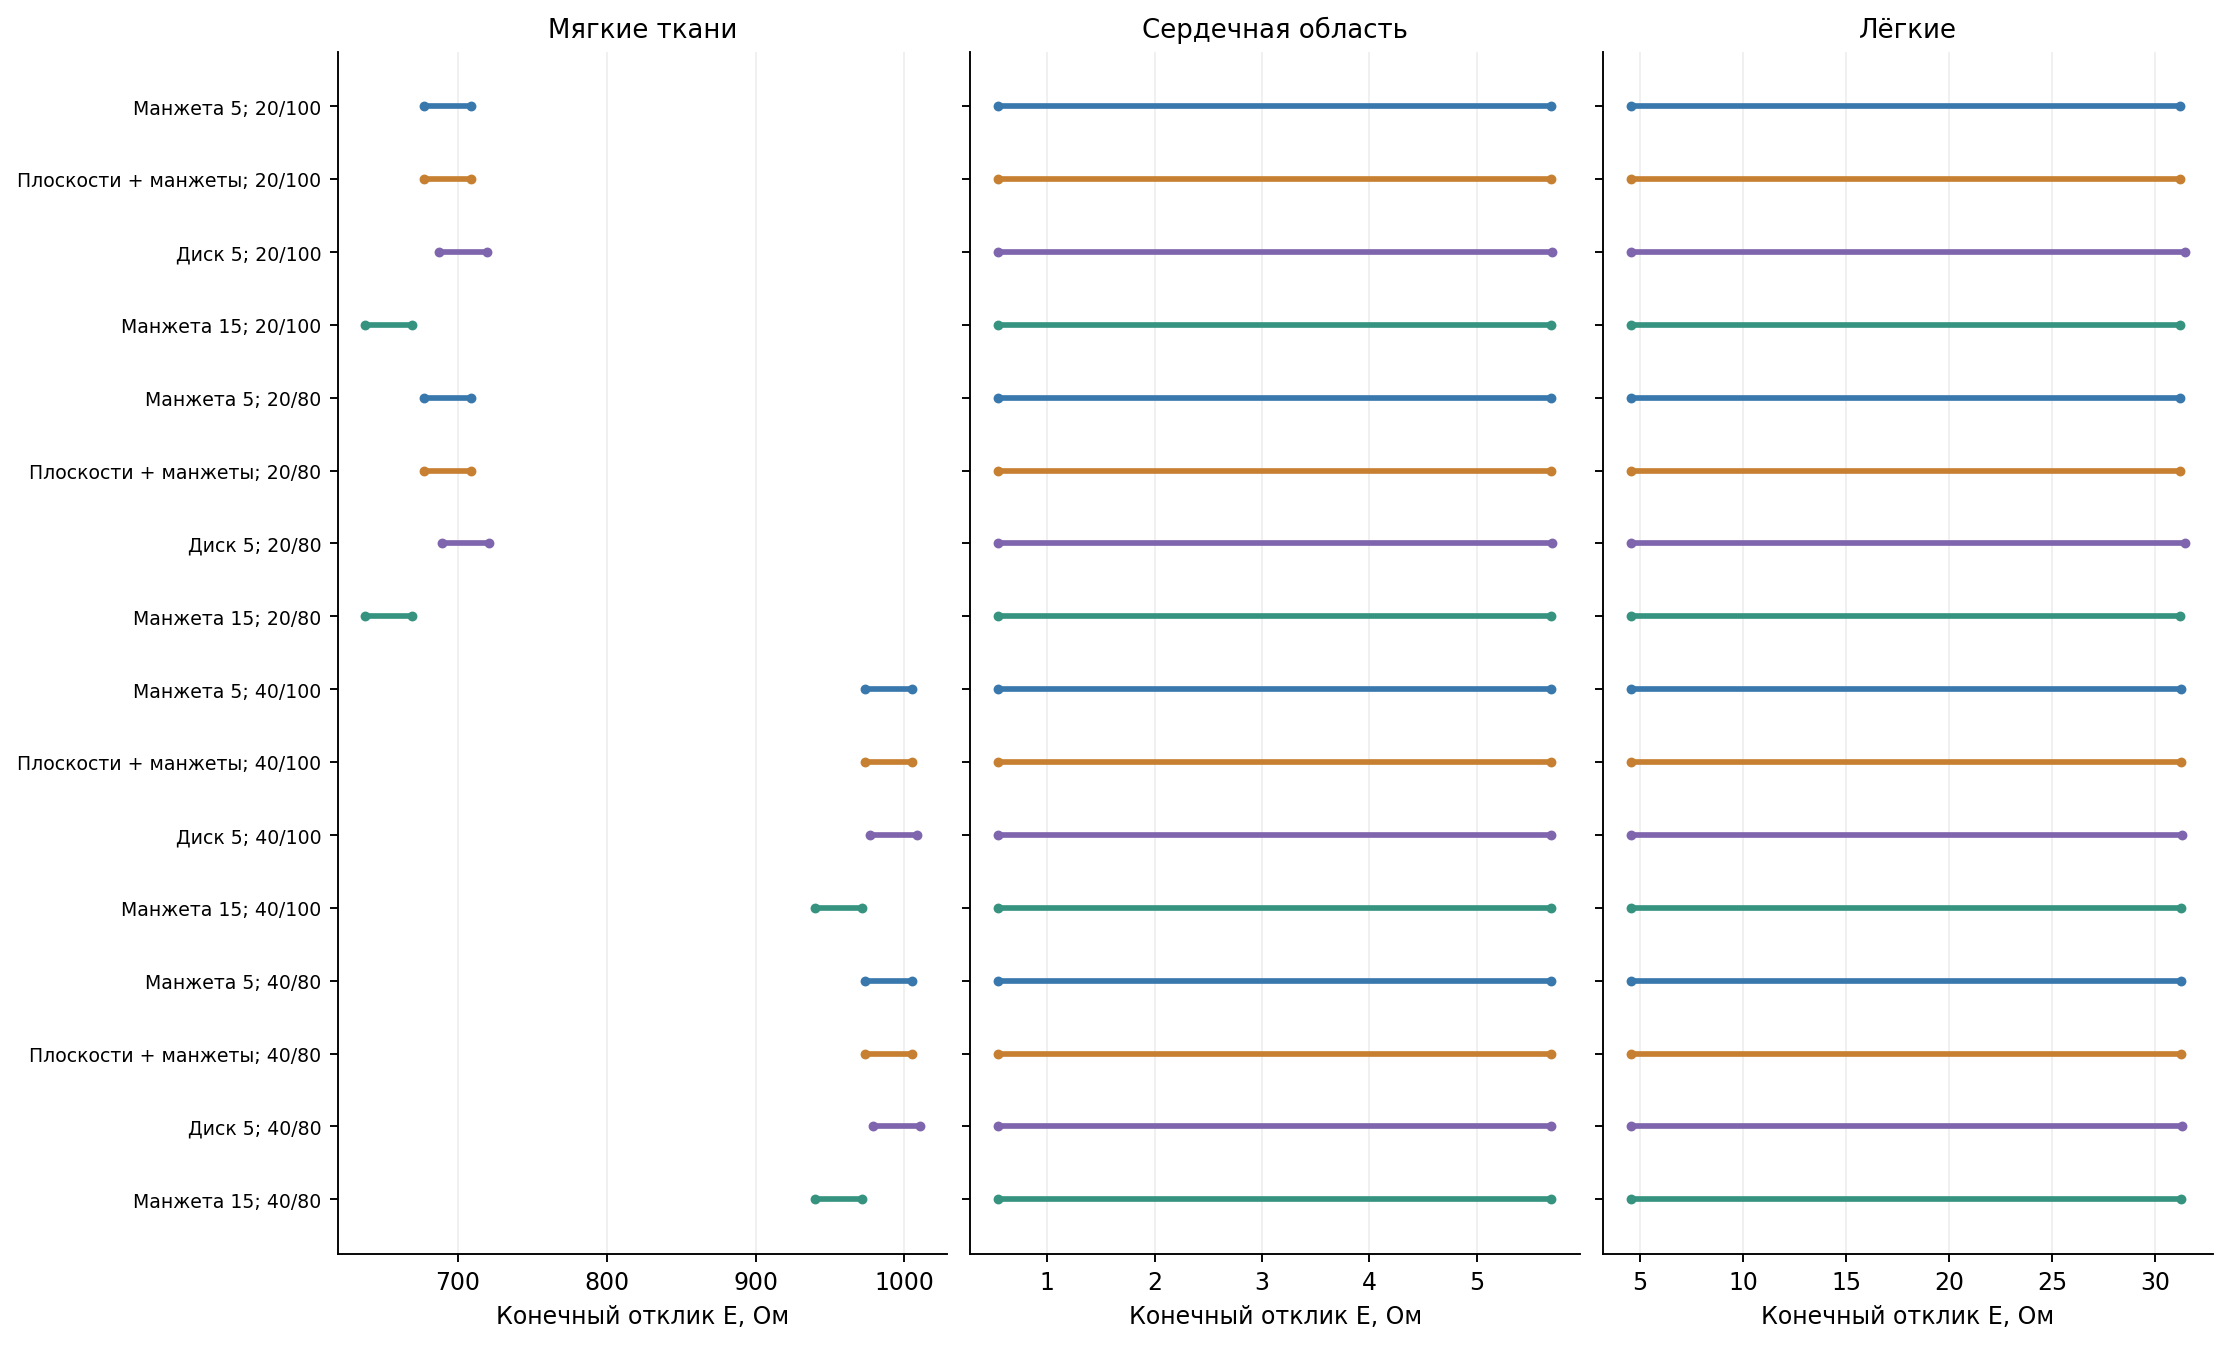

In [15]:
report.endpoints(r)

**Рисунок 9.** Разность импедансов между граничными значениями ρ одного компартмента при неизменных остальных параметрах. Для мягких тканей и сердца на сборку доступны по шесть фоновых сочетаний, для лёгких — девять. Отрезки показывают минимум и максимум конечного отклика по этим фонам. Каждая разность основана на двух рассчитанных состояниях, поэтому широкие интервалы не требуют предположения о линейности *Z*.

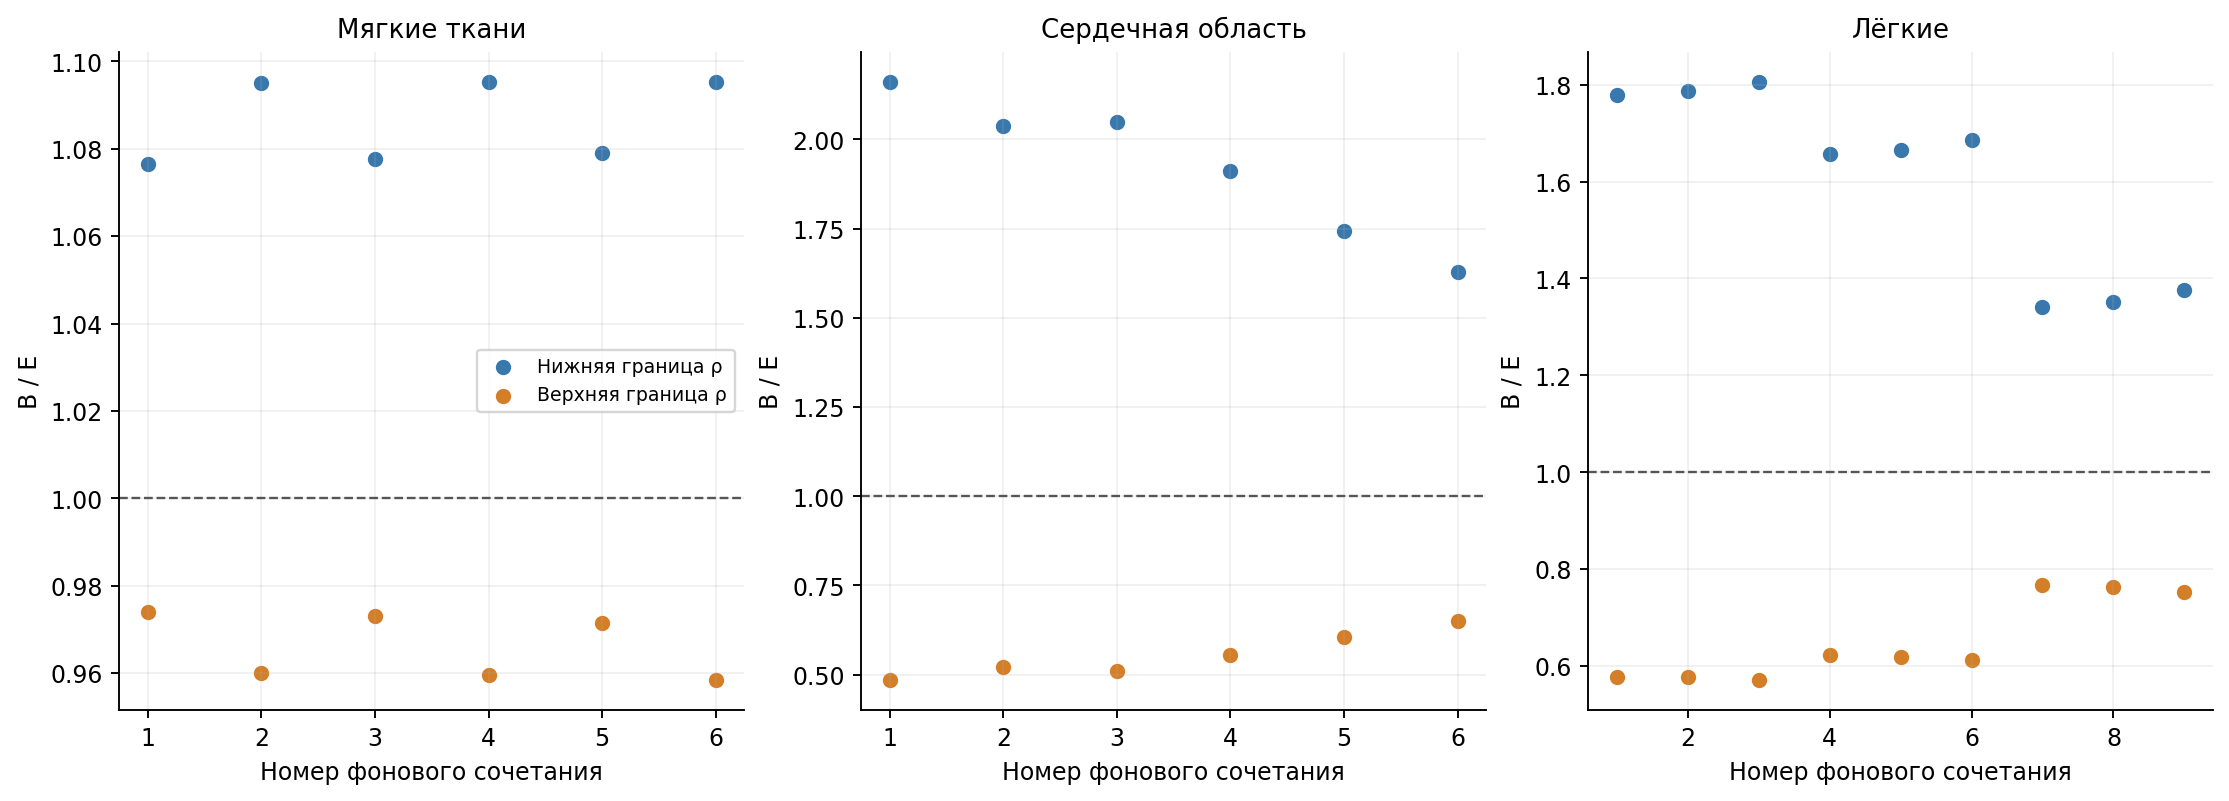

In [16]:
report.finite_vs_local(r)

**Рисунок 10.** Различие между локально масштабированной производной *B* и конечным откликом *E* для опорной сборки. Для каждого фонового сочетания показаны отношение *B/E* на нижней и верхней границах собственного ρ и опорная линия 1. Совпадение с единицей означает согласие локального линейного масштаба с конечной разностью именно в данном случае. Отклонение показывает, почему нельзя называть произведение производной на широкий диапазон фактически рассчитанным изменением импеданса.

Знаковая разность импедансов определяется интегралом производной по целевой координате; показатель E равен модулю этого интеграла. Поэтому она удобна для ответа «насколько изменится выход между двумя крайними состояниями», а производная — для ответа «насколько заметно небольшое изменение около данного состояния». Оба представления нужны при дальнейшем выборе целевого измерительного канала.

### 6.4. Результат проверки параметрической сетки

**Таблица 5.** Результаты проверки производных и избирательности по каждому компартменту.

In [17]:
report.audit_summary(r)

**Результат независимой проверки.** Из 192 проверок производной не прошли критерий 64; проверок избирательности с превышением допуска — 0. Максимальная относительная ошибка производной — 25,22%, базового импеданса — 1,68%; максимальная абсолютная ошибка избирательности — 0,233 процентного пункта.

Компартмент,"max ошибка S, %",Не прошли,Всего проверок,"max ошибка Q, п.п."
Мягкие ткани,"2,15",0,64,"0,233"
Сердечная область,"19,88",32,64,"0,101"
Лёгкие,"25,22",32,64,"0,213"


**Вывод о покрытии.** Исходная сетка недостаточна для принятой точности описания производных между узлами. Сохранённые значения в самих узлах от этого не становятся неверными. Недостаточность относится к восстановлению зависимости по редкой сетке и к претензии на устойчивый выбор сборок во всём диапазоне. Требуется сгущение параметрической сетки; объявлять метод полностью проверенным или сборку окончательно оптимальной нельзя.

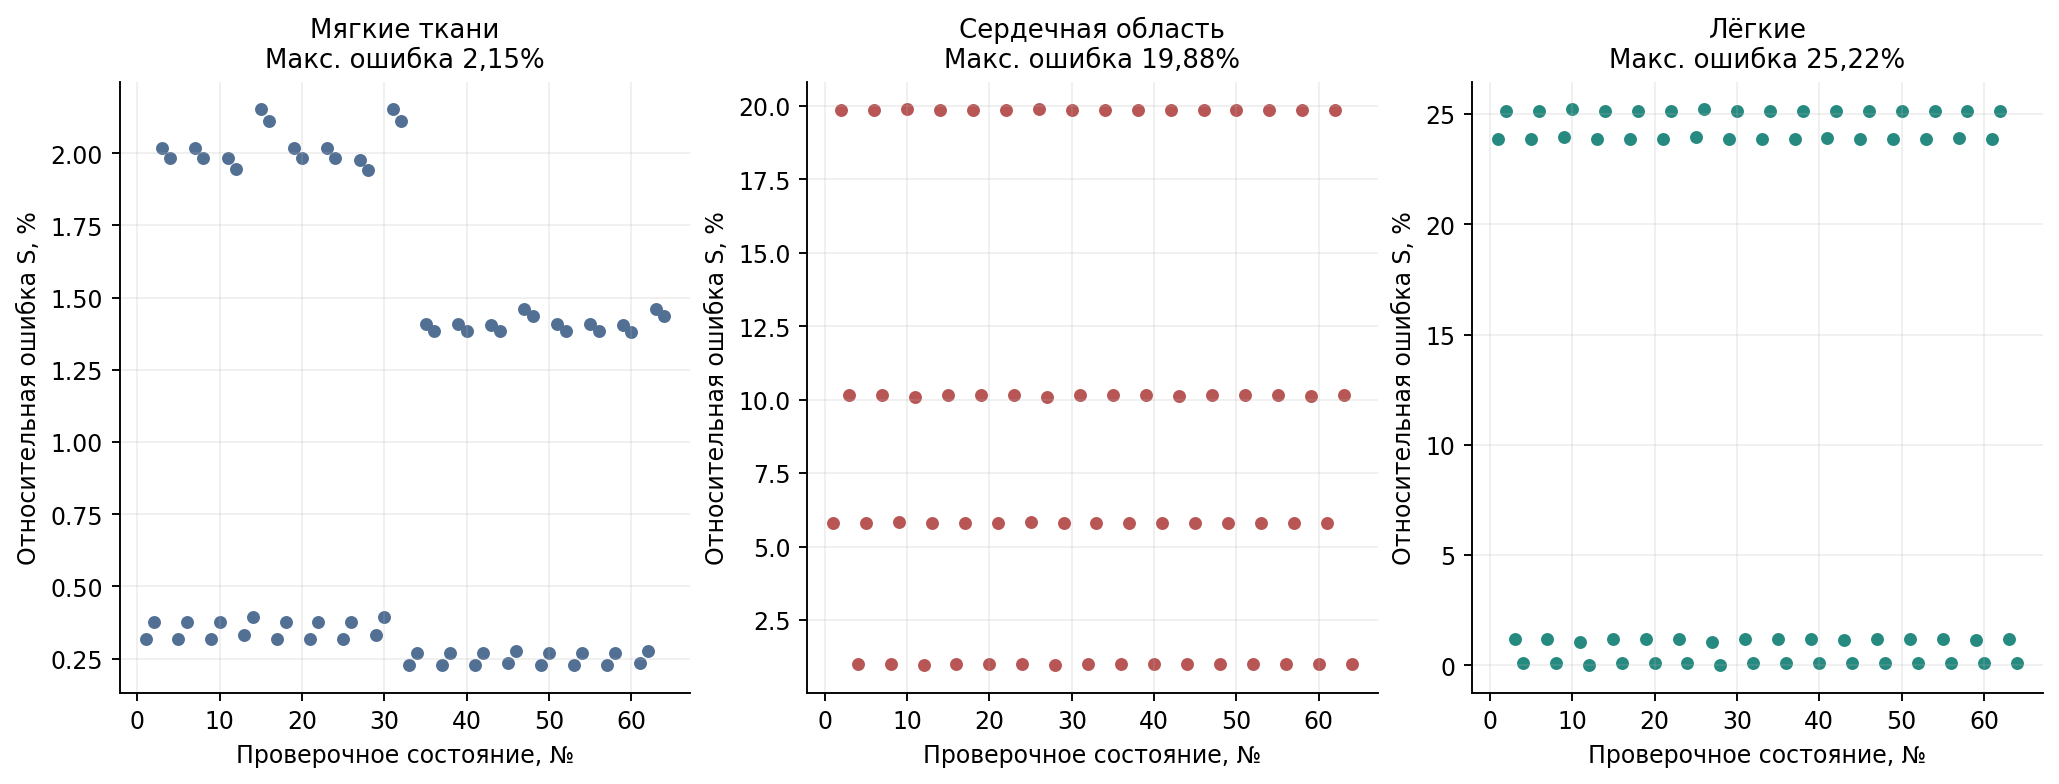

In [18]:
report.audit_error(r)

**Рисунок 11.** Относительная ошибка интерполированной производной в 64 проверочных состояниях. Для каждого компартмента показаны все проверки и максимальная ошибка по сборкам. Для решения о прохождении применяется полный критерий (7), а не только относительный процент. Ошибка интерполяции показывает неполноту описания между узлами; она не равна невязке линейного решателя.

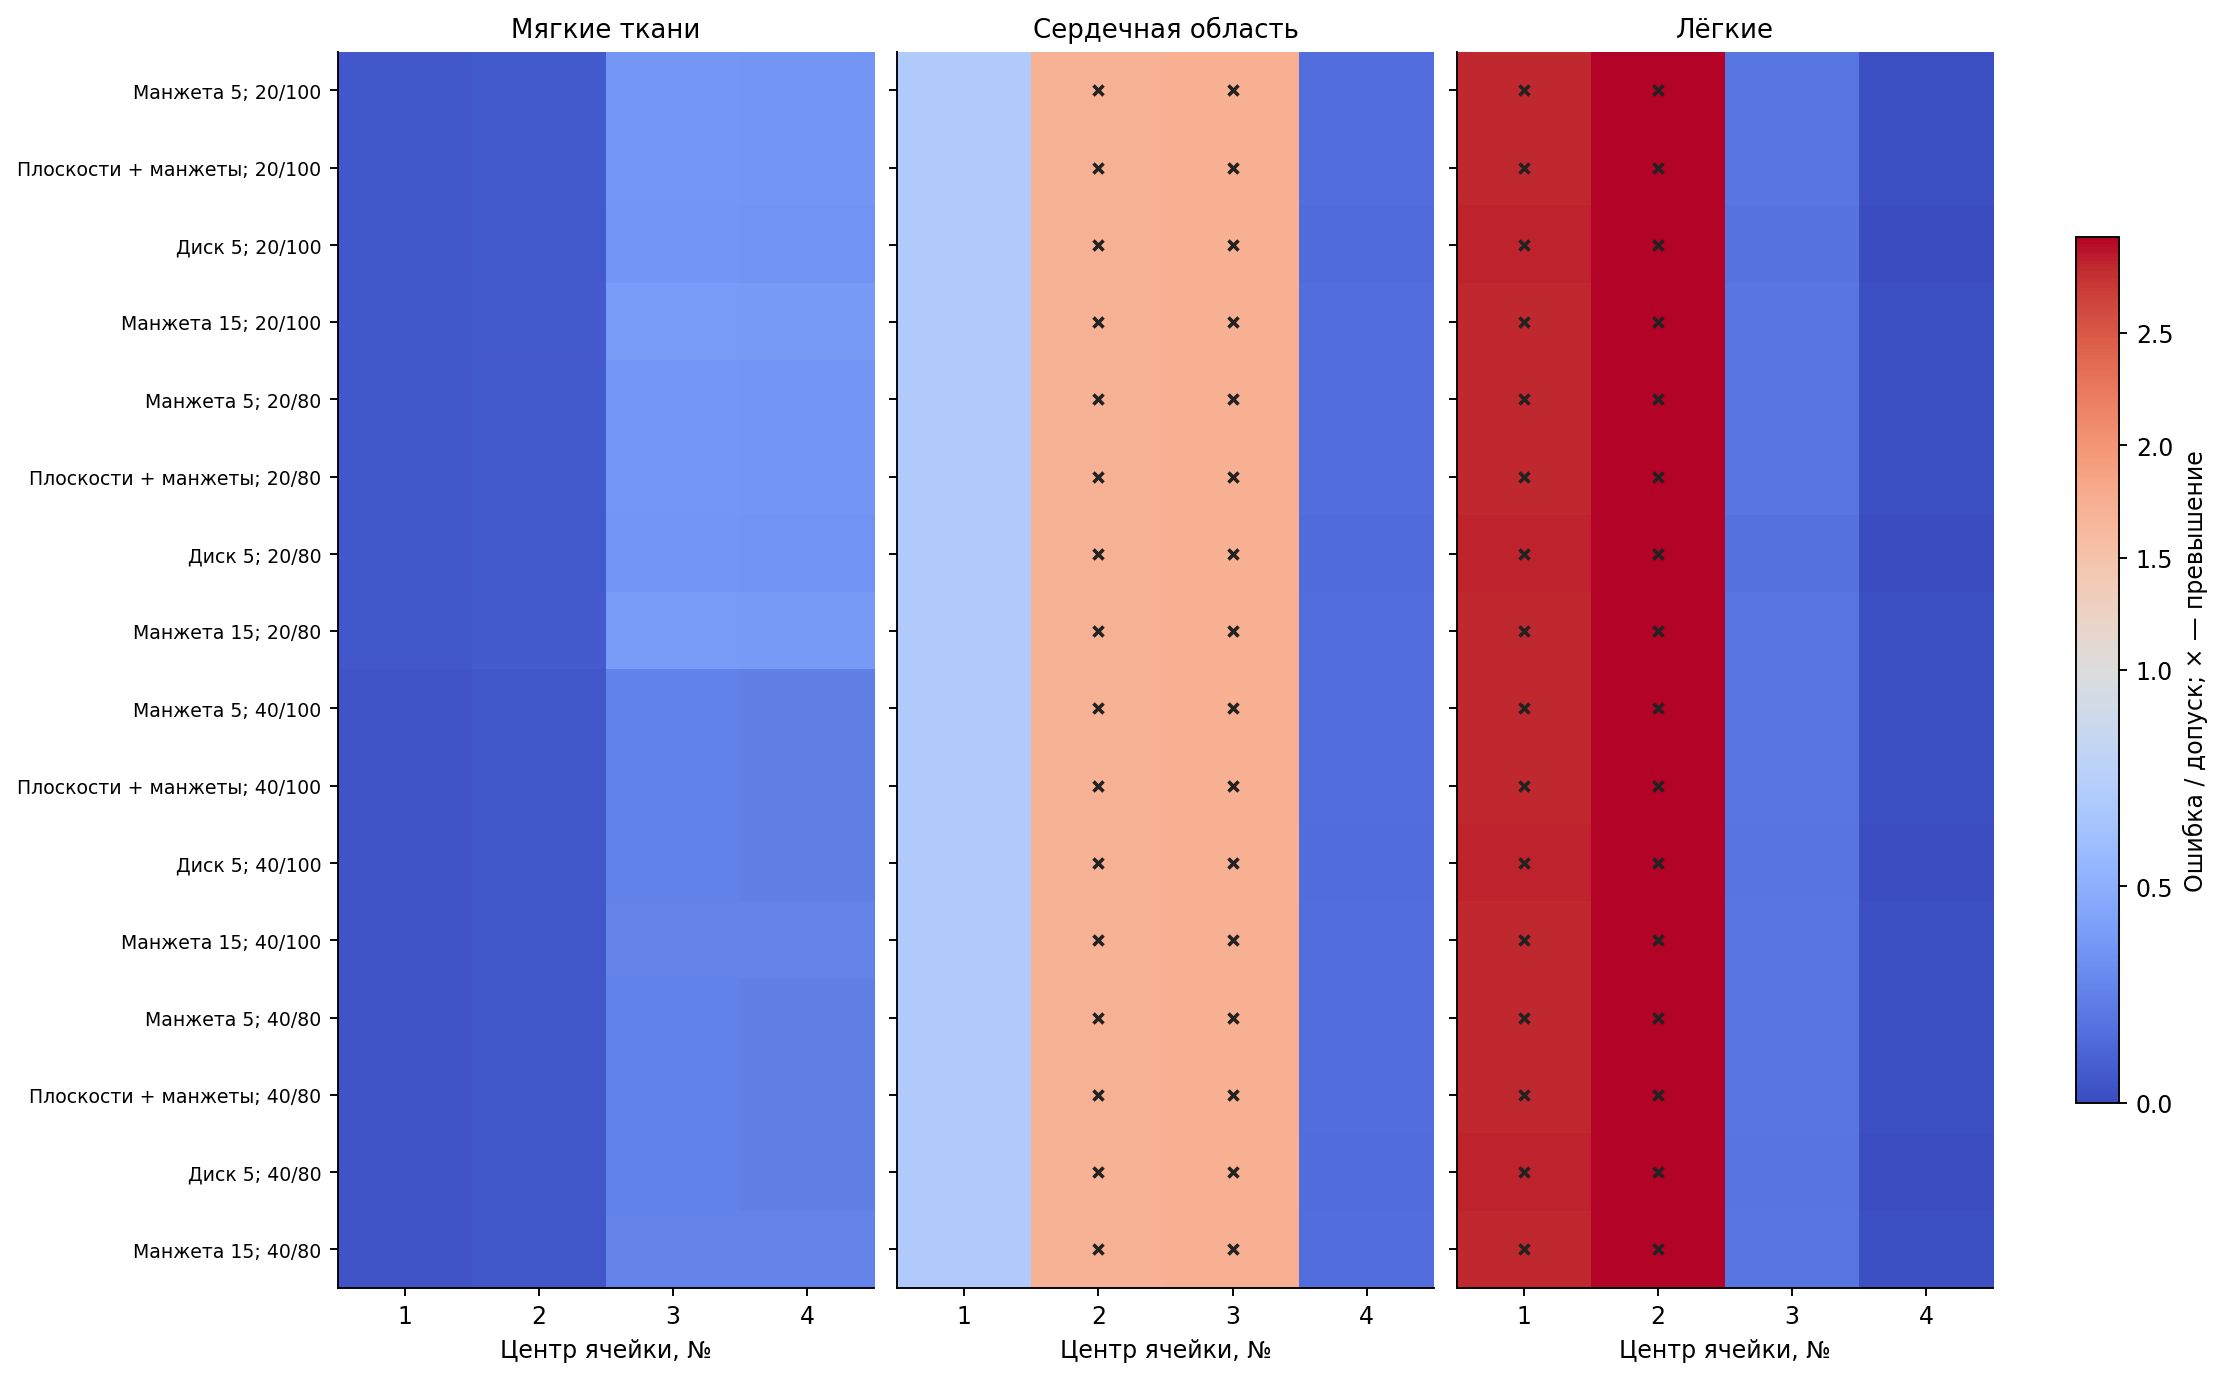

In [19]:
report.audit_heat(r)

**Рисунок 12.** Отношение фактической ошибки производной к допустимой по критерию (7). Столбцы — четыре центра ячеек, строки — сборки. Значение больше 1 означает непрохождение. Карта показывает, в каких областях исходной сетки требуется уточнение. Номера центров соответствуют порядку сочетаний возрастающих середин ρ мягких тканей и сердца; середина диапазона лёгких одна.

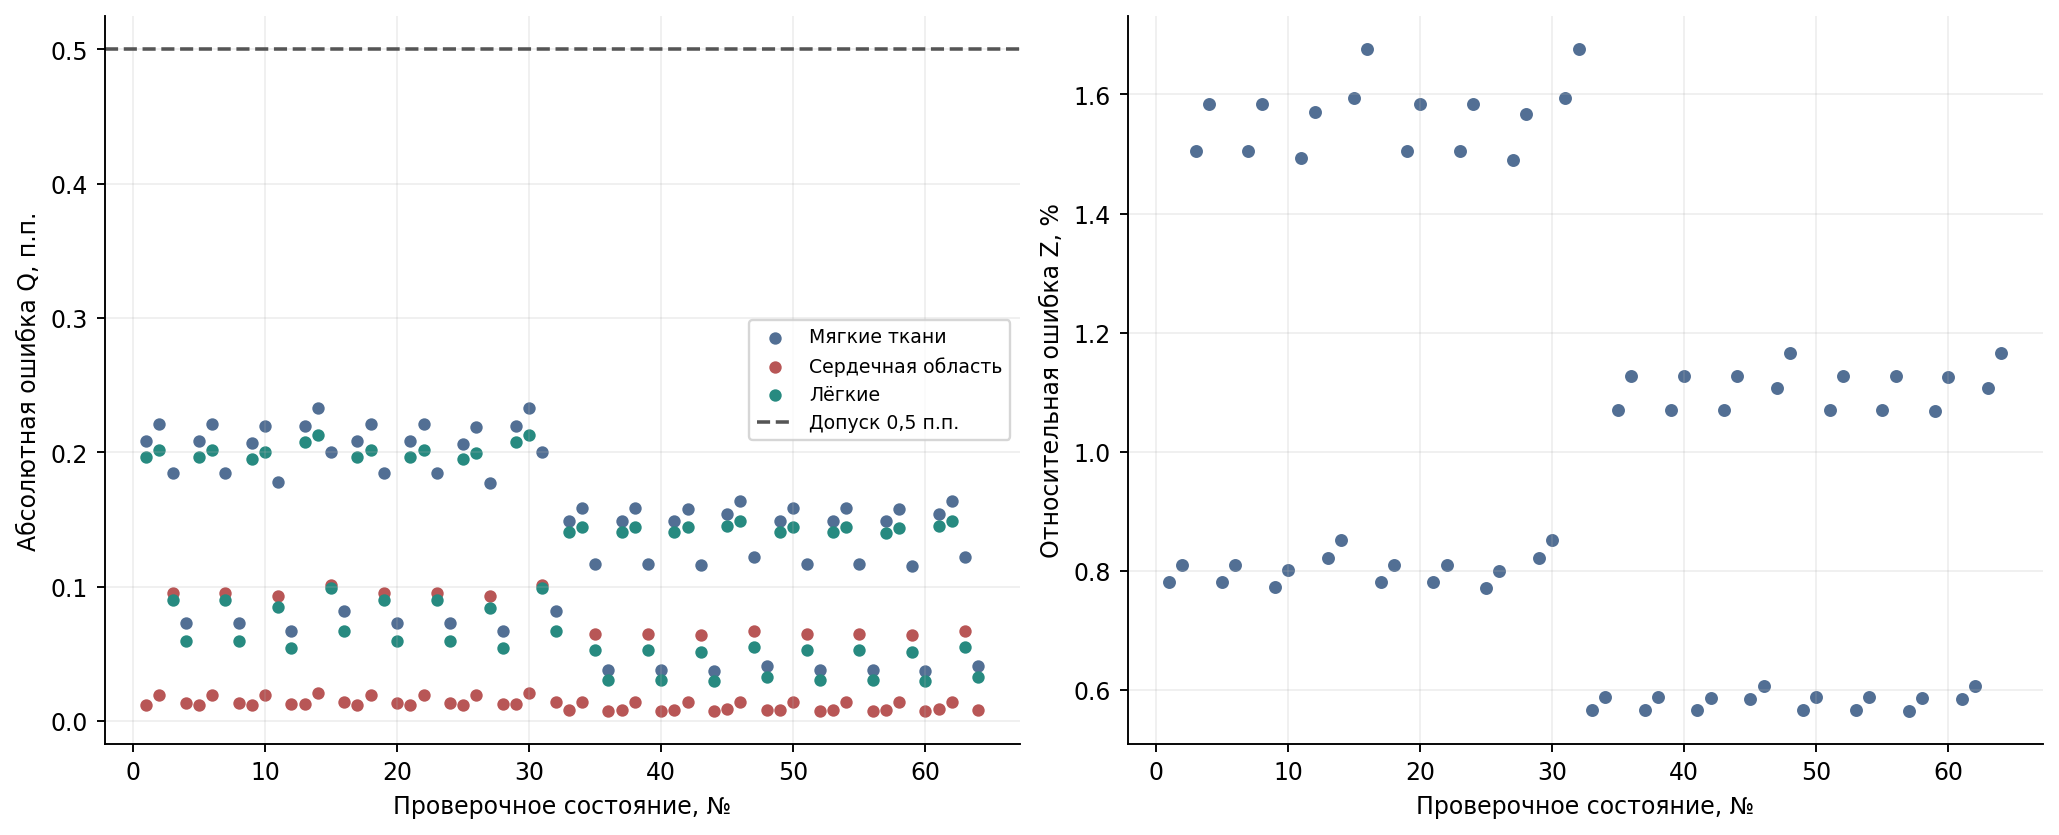

In [20]:
report.audit_selectivity(r)

**Рисунок 13.** Ошибка избирательности в процентных пунктах и относительная ошибка базового импеданса. Горизонтальная линия для *Q* показывает выбранный допуск 0,5 процентного пункта. Совместное рассмотрение рисунков 11–13 отделяет точность базового выхода от точности интересующей производной: удовлетворительное воспроизведение *Z* само по себе не обеспечивает удовлетворительного воспроизведения чувствительности.

### 6.5. Численное сравнение сборок

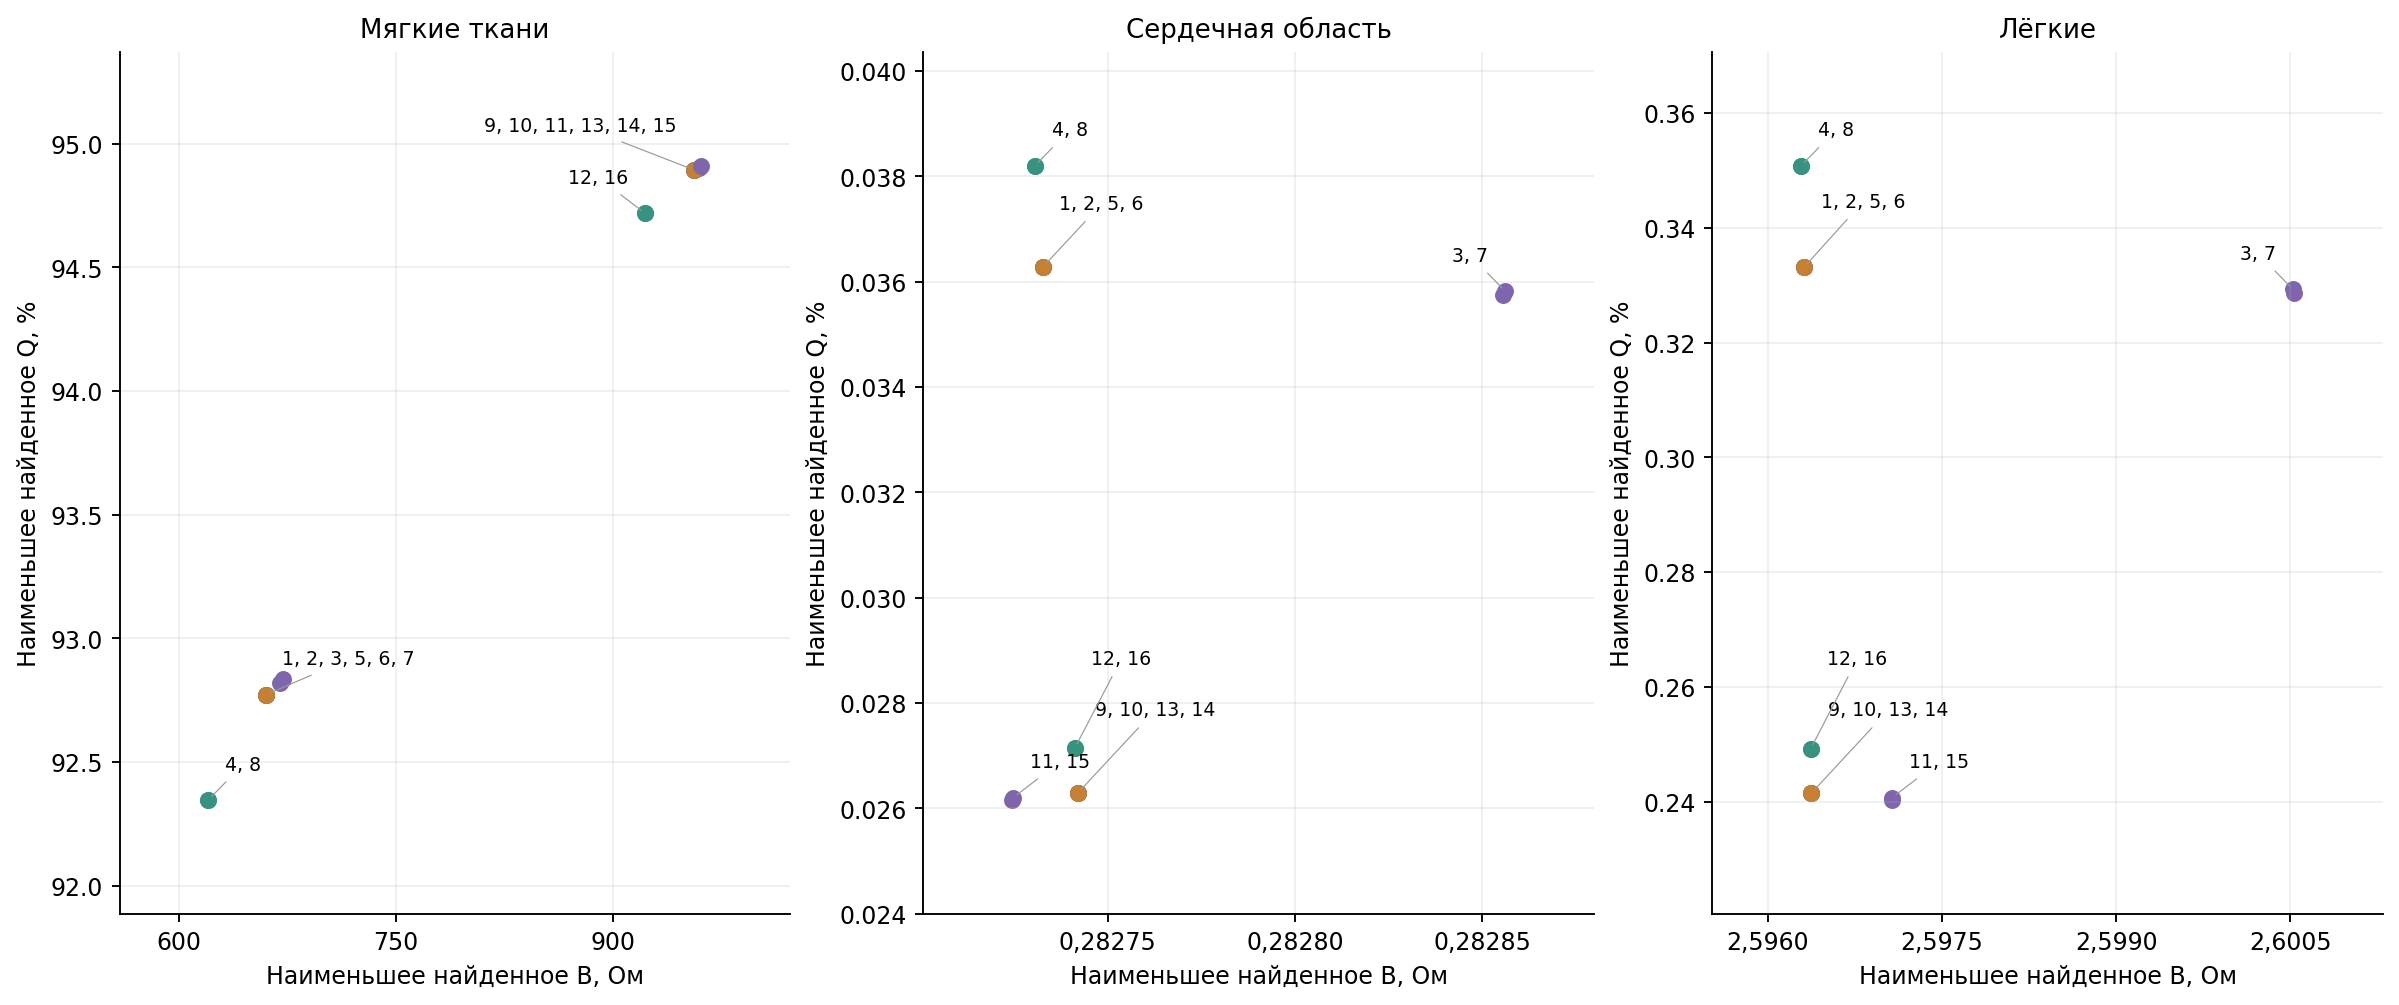

In [21]:
report.pareto(r)

**Рисунок 14.** Два критерия для каждой целевой области: наименьшая найденная линейно масштабированная чувствительность и наименьшая найденная избирательность. Номера сборок соответствуют таблице 4; близко расположенные точки снабжены общей подписью с перечислением номеров. Каждая точка — сборка; направления увеличения обоих показателей соответствуют предпочтению по этим двум критериям. Минимумы могут достигаться в разных исходных состояниях, поэтому точка не изображает одно конкретное физиологическое состояние. Преимущество по этим сеточным критериям ещё не является гарантированным преимуществом во всей непрерывной области.

**Таблица 6.** Условные лидеры по наименьшим найденным значениям амплитудного показателя и избирательности.

In [22]:
report.comparison(r)

Цель,Наибольшее min B: сборка,"min B, Ом",Наибольшее min Q: сборка,"min Q, %"
Мягкие ткани,Диск 5; 40/80,"960,889",Диск 5; 40/80,"94,9111"
Сердечная область,Диск 5; 20/100,"0,283",Манжета 15; 20/100,"0,0382"
Лёгкие,Диск 5; 20/80,"2,601",Манжета 15; 20/100,"0,3508"


**Условное сравнение.** Таблица указывает лидеров по двум раздельным сеточным критериям. Различие названий в двух столбцах означает зависимость выбора от задачи. Даже совпадение лидеров не доказывает общего оптимума: набор сборок ограничен, а непрерывное покрытие не сертифицировано. Числа служат исходными показателями для уточнения.

**Различие при одинаковом фоне.** Размах производной между всеми 16 сборками, отнесённый к её наибольшему модулю в том же состоянии, составляет: мягкие ткани — 31,60–35,45%; сердечная область — 0,02–0,40%; лёгкие — 0,16–0,91%. Для сердца и лёгких эти различия малы по сравнению с установленной ошибкой описания между узлами. Однако ошибки разных сборок могут быть связаны: их нельзя автоматически считать погрешностью разности между сборками. Для проверки предпочтения нужно контролировать и сами парные различия при сгущении. Лидирующее место в таблице поэтому не следует трактовать как доказанное практическое преимущество. Избирательность может улучшаться за счёт уменьшения мягкотканного влияния при почти неизменной абсолютной чувствительности к сердцу или лёгким.

Для практически применимого выбора необходимо сохранять два уровня оценки. На первом уровне рассматриваются абсолютная чувствительность к цели и относительное влияние других параметров при общем литературном масштабе. На втором проверяется, остаётся ли предпочтение устойчивым при изменении исходных параметров, сгущении сетки и допустимых изменениях контакта и геометрии. Результаты текущего уровня позволяют описать сборки числами, но не отменяют второй уровень.

## 7. Проверки, ограничения и статус выводов

**Таблица 7.** Раздельный статус численных, методических и экспериментальных проверок. Малые невязки подтверждают решение заявленной дискретной системы. Контроль взаимности подтверждает внутреннюю согласованность линейной постановки. Ни одна из этих проверок сама по себе не устанавливает точность описания человеческого тела.

In [23]:
report.validation(r)

Проверка,Результат или ограничение
Происхождение результатов,Проверены контрольные суммы исходных таблиц и всех 16 новых запусков
Новые прямые решения,64 состояния; max относительная невязка 2.548e-10
Взаимность,max |Z − Z взаимн.| = 1.536e-07 Ом
Переход σ → ρ,Правило цепочки; аналитические тесты последовательных и параллельных сопротивлений
Плотность параметрической сетки,Недостаточна по проверке производных
Пространственная сходимость,В этой серии не исследована
Альтернативные тканевые профили,Расхождение отмечено; отдельная FEM-матрица не выполнена
Физическая и экспериментальная валидация,В этой серии не выполнена


**Результат математической модели.** Производные и конечные отклики рассчитаны для фиксированных масок, контактов и токовой схемы. Они учитывают различие размеров компартментов и перераспределение токового поля. При переходе к ρ сохранена размерность и знак по правилу цепочки. Неопределённость параметрического покрытия оценена независимыми решениями между исходными узлами.

**Нерешённый вопрос.** Численная точность относительно непрерывной пространственной задачи в этой серии не оценивалась повторным сгущением FEM-сетки. Ошибки ручной сегментации, модельных рук, положения и площади электродов, контактного импеданса и электрической изотропии остаются отдельными источниками расхождения. Их совместное распределение неизвестно. Полученные диапазоны не включают автоматически их влияние.

**Нерешённый вопрос.** Отсутствуют независимое измерение заданных тканевых параметров у этого добровольца и экспериментальное подтверждение каждой рассчитанной сборки в тех же условиях. Сопоставление с исходными записями должно учитывать прибор, калибровку, фактическую установку и различие состояния дыхания. В частности, расчёт на КТ вдоха при изменении ρ лёгких не заменяет геометрическую модель выдоха.

**Методическое ограничение.** Один скалярный выход в общем случае не позволяет независимо восстановить три неизвестных параметра. Высокая целевая чувствительность сама по себе не доказывает идентифицируемости. Если планируется совместное восстановление нескольких параметров по нескольким каналам, потребуются матрица их производных, анализ независимости её столбцов и измерительно обоснованная модель ошибок. Эти задачи следуют после выбора целевых каналов и не решаются произвольным добавлением одинакового процентного шума.

## 8. Применение к новым пользовательским сборкам

Новая сборка задаётся геометрией физических контактов и отдельно векторами токового возбуждения и измерения. Геометрическая часть должна сформировать совместимую контактную матрицу для той же FEM-сетки, с проверяемыми площадями, единицами и порядком электродов. Программный контракт допускает произвольное число контактов и каналов; перенос текущих результатов на новые координаты без нового прямого расчёта недопустим.

Для повторного исследования сохраняются частота, определение компартментов и общий профиль диапазонов. Генератор конфигурации создаёт полный декартов перебор равномерных узлов по ρ, переводя их в σ только на входе решателя. Числа уровней 3, 5 и 9 дают вложенные равномерные сетки. При трёх изменяемых параметрах это 27, 125 и 729 состояний на сборку; стоимость растёт быстро, поэтому число уровней является результатом проверки достаточности, а не заранее известной физиологической константой.

После каждого уровня требуется сравнивать найденные экстремумы и порядок сборок, а также добавлять независимые внутренние состояния для проверки описания между узлами. Если соответствующие области дают неприемлемую ошибку, сетка уточняется. Простое совпадение производных в общих узлах двух сеток ожидаемо для одинаковой FEM-задачи и не доказывает достаточности покрытия. Историческая неравномерная сетка текущего отчёта служит исходным материалом проверки и не тождественна равномерной сетке из трёх уровней ρ.

In [24]:
report.reproduction(r)

Воспроизводимые материалы находятся в папке проекта `MATLAB_TRKG4_real_subjects`. Профиль диапазонов: `output/exploratory/resistivity_sensitivity_20260910/literature/frozen/rho_profile.json`. Конфигурации проверочных состояний находятся в соседней папке `studies`, результаты — в `fem`, сводки — в `analysis`. Скрипт `tools/analyze_resistivity_coverage.py` проверяет завершение всех запусков и строит таблицы. Ноутбук читает готовые результаты и не запускает FEM автоматически.

Для новой геометрии сначала подготавливается совместимая конфигурация контактов. Из корня MATLAB-проекта пример генерации полной сетки:

```text
python tools/configure_resistivity_grid.py --template new_assembly.json --profile output/exploratory/resistivity_sensitivity_20260910/literature/frozen/rho_profile.json --levels 5 --output new_assembly_rho5.json
```

Затем в MATLAB вызывается `run_pipeline` с профилем `electrode_sensitivity`, созданным файлом в `StudyFile`, новой папкой `OutputDirectory`, локальными путями к Python и зависимостям. Модуль `resistivity_sensitivity_metrics.py` предоставляет `conductivity_to_resistivity` и `range_scaled_metrics`; порядок столбцов параметров должен совпадать с порядком ширин интервалов. Сводки формируются отдельно для каждой сборки, канала и целевого компартмента.

Текущие расчёты повторяются через `tools/run_resistivity_coverage.m`, если переменная `rho_python_executable` содержит путь установленного Python. Завершённые совпадающие результаты проверяются и используются повторно; незавершённая папка не принимается за готовый расчёт. HTML экспортируется из исполненного ноутбука с удалением программных входов из разметки. Исходный код остаётся в ноутбуке и файлах проекта.

**Последовательность следующего применения.** Автор задаёт новые контакты и целевой компартмент; формируется проверенная геометрическая конфигурация; выбирается общий тканевый профиль; выполняются совместные состояния и контроль покрытия; строятся таблицы *S*, *B*, *Q*, *N* и *E*; только после этого принимается условное решение о предпочтительных сборках. Пульсовые и дыхательные масштабы, а затем координаты и радиус эквивалентной сферы вводятся отдельными этапами с собственными исходными данными и проверками.

## 9. Заключение

In [25]:
report.conclusion(r)

Получено количественное описание 16 сборок через производные по ρ целых компартментов, показатели при общем литературном масштабе и реальные разности импеданса между границами диапазонов. Объём компартмента учитывается полевым расчётом; дополнительное деление основной производной на объём не требуется.

В принятом профиле и рассмотренной геометрии преобладает чувствительность к объединённому мягкотканному фону. Этот вывод относится к модели исходных свойств и не устанавливает состав пульсового или дыхательного сигнала.

Независимые промежуточные решения показали максимальную ошибку интерполяции производной 25,2%. Исходная сетка недостаточна по заданному критерию. Следующий необходимый расчёт для устойчивого выбора — уточнение совместной параметрической сетки новых сборок с повторным контролем производных. Метод задан и реализован как исследовательская процедура; достаточность покрытия, физиологическая полнота интервалов и оптимальность сборки пока не доказаны.

## Литература

1. IT’IS Foundation. **Tissue Properties Database V5.0.** 2025. DOI: [10.13099/VIP21000-05-0](https://itis.swiss/virtual-population/tissue-properties/downloads/database-v5-0). Численные частотные ориентиры извлечены из коэффициентов основного диэлектрического профиля; версия и контрольная сумма архива сохранены вместе с результатами.
2. IT’IS Foundation. **Dielectric Properties.** [Описание частотной модели и источника Gabriel](https://itis.swiss/virtual-population/tissue-properties/database/dielectric-properties). Дата обращения: 10.09.2026.
3. Kangasmaa O., Laakso I., Schmid G. **Estimating Human Fat and Muscle Conductivity From 100 Hz to 1 MHz Using Measurements and Modelling.** Bioelectromagnetics. 2025;46(1):e22541. DOI: [10.1002/bem.22541](https://onlinelibrary.wiley.com/doi/10.1002/bem.22541). Для сопоставления использованы модель (10) и коэффициенты таблицы 3.
4. Gabriel C., Peyman A., Grant E. H. **Electrical conductivity of tissue at frequencies below 1 MHz.** Physics in Medicine and Biology. 2009;54(16):4863–4878. DOI: [10.1088/0031-9155/54/16/002](https://researchportal.ukhsa.gov.uk/en/publications/electrical-conductivity-of-tissue-at-frequencies-below-1-mhz/). Проверены библиографические сведения и аннотация; численные границы текущего профиля из этой статьи напрямую не извлекались.